In [1]:

import sys
import pandas as pd
import numpy as np
import torch
import importlib
import json
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, VPacker, HPacker, DrawingArea
from matplotlib.patches import Rectangle

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    f1_score
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing")
DATA_DIR = PROJECT_DIR / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
RESULT_DIR = PROJECT_DIR / "testing_results"

sys.path.append(str(PROJECT_DIR))

import models.tf_to_tg as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module
from scripts.train_tf_to_tg_model import TFTGEdgeBagDataset, collate_tftg_edge_bags
import plotting_utils
import stat_utils
import utils
import warnings
import config

warnings.filterwarnings(
    "ignore",
    message="You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)

tf_tg_input_cache_dir = DATA_DIR / "tf_tg_training_cache"

all_evaluation_plot_dir = PROJECT_DIR / "plots" / "model_vs_test_set_evaluation_figs"
all_evaluation_plot_dir.mkdir(exist_ok=True)


## Functions

### Load the latest model checkpoints for each sample

In [2]:
tf_tg_model_checkpoints = {
    "mESC": {
        # "E7.5_rep1": CHKPT_DIR / "mESC" / "E7.5_rep1" / "tf_tg_train_E7.5_rep1_3675131" / "epoch_11_best_model.ckpt",
        "E7.5_rep1": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E7.5_rep1"),
        "E7.5_rep2": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E7.5_rep2"),
        "E8.5_rep1": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E8.5_rep1", training_number="3691937"),
        "E8.5_rep2": utils.find_latest_checkpoint(CHKPT_DIR, "mESC", "E8.5_rep2"),
    },
    "iPSC": {
        "WT_D13_rep1": utils.find_latest_checkpoint(CHKPT_DIR, "iPSC", "WT_D13_rep1"),
    },
    "Macrophage": {
        "buffer_1": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_1", training_number="3685893"),
        "buffer_2": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_2"),
        "buffer_3": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_3"),
        "buffer_4": utils.find_latest_checkpoint(CHKPT_DIR, "Macrophage", "buffer_4"),
    },
    "K562": {
        "sample_1": utils.find_latest_checkpoint(CHKPT_DIR, "K562", "sample_1"),
    },
    "mouse_liver": {
        "liver_1": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_liver", "liver_1"),
        "liver_3": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_liver", "liver_3")
    },
    "mouse_hepatocytes": {
        "hepatocytes_1": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_hepatocytes", "hepatocytes_1"),
        "hepatocytes_3": utils.find_latest_checkpoint(CHKPT_DIR, "mouse_hepatocytes", "hepatocytes_3"),
    }
}

INFO - Latest checkpoint for mESC E7.5_rep1: Job 3704585 Epoch 73
INFO - Latest checkpoint for mESC E7.5_rep2: Job 3696113 Epoch 76
INFO - Latest checkpoint for mESC E8.5_rep1: Job 3691937 Epoch 42
INFO - Latest checkpoint for mESC E8.5_rep2: Job 3696124 Epoch 67
INFO - Latest checkpoint for iPSC WT_D13_rep1: Job 3709598 Epoch 52
INFO - Latest checkpoint for Macrophage buffer_1: Job 3685893 Epoch 152
INFO - Latest checkpoint for Macrophage buffer_2: Job 3713132 Epoch 34
INFO - Latest checkpoint for Macrophage buffer_3: Job 3704579 Epoch 52
INFO - Latest checkpoint for Macrophage buffer_4: Job 3696147 Epoch 209
INFO - Latest checkpoint for K562 sample_1: Job 3712050 Epoch 01
INFO - Latest checkpoint for mouse_liver liver_1: Job 3708415 Epoch 42
INFO - Latest checkpoint for mouse_liver liver_3: Job 3708657 Epoch 48
INFO - Latest checkpoint for mouse_hepatocytes hepatocytes_1: Job 3709466 Epoch 33
INFO - Latest checkpoint for mouse_hepatocytes hepatocytes_3: Job 3709471 Epoch 57


### Run model predictions on the trained dataset

In [7]:
def run_prediction_vs_test_set(
    tf_tg_model_checkpoints: dict,
    model_cell_type: str,
    model_training_sample: str,
    test_set_cell_type: str,
    evaluation_sample: str,
    dataset_split_type: str = "test",
    subset_size: int | None = None,
    show_progress_bar: bool = True,
    compile_model: bool = True,
    ):
    
    tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][model_training_sample]
    tf_dna_model_chkpt = config.tf_dna_model_checkpoints[model_cell_type]
    
    if tf_tg_model_chkpt is None:
        logging.warning(f"Skipping evaluation for {model_cell_type} {model_training_sample} → {test_set_cell_type} {evaluation_sample} due to missing TF-TG checkpoint")
        return None


    cell_type_cache_dir = DATA_DIR / f"{test_set_cell_type}_cache"

    # print(f"Loading cached dataset with subset size: {subset_size}")
    data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = utils.load_training_cache_dataset(
        sample_name=evaluation_sample,
        cell_type_cache_dir=cell_type_cache_dir,
        split_type=dataset_split_type,
        subset_size=subset_size
        )
    
    tf_tg_model = utils.load_tf_tg_regulation_model(
        tf_dna_model_chkpt, 
        tf_tg_model_chkpt, 
        tf_embeddings_tensor, 
        tf_mask_tensor
        )

    # print("Moving model to device")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = tf_tg_model.model
    model = model.to(device)

    criterion = torch.nn.BCEWithLogitsLoss()
    score_threshold = 0.5
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model.eval()

    total_loss = 0.0
    n_edges = 0

    all_scores = []
    all_labels = []
    plot_data = {}
    
    if compile_model:
        print("Compiling model for faster evaluation")
        model = torch.compile(model)

    # print(f"Evaluating on {dataset_split_type} set")
    with torch.inference_mode():
        for batch in tqdm(data_loader, desc="Evaluating", ncols=100, disable=not show_progress_bar):
            # set batch peak_distance values to zero to eliminate distance information from predictions
            # batch["peak_distance"] = torch.zeros_like(batch["peak_distance"])
            
            batch = tf_to_tg_module.move_batch_to_device(batch, device)

            labels = batch["label"]
            cell_mask = batch["cell_mask"]
            E, C = cell_mask.shape

            edge_logits, _ = model.forward(
                tf_embedding=batch["tf_embedding"],
                tf_mask=batch["tf_mask"],
                peak_sequences=batch["peak_sequences"],
                peak_accessibility=batch["peak_accessibility"],
                peak_distance=batch["peak_distance"],
                tf_expression=batch["tf_expression"],
                tg_expression=batch["tg_expression"],
                peak_mask=batch.get("peak_mask", None),
                cell_mask=cell_mask,
                pooling_mode=pooling_mode,
                pooling_temperature=pooling_temperature,
            )

            loss = criterion(edge_logits, labels)

            total_loss += loss.item() * E
            n_edges += E

            scores = torch.sigmoid(edge_logits)

            all_scores.append(scores.detach().cpu().numpy().ravel())
            all_labels.append(labels.detach().cpu().numpy().ravel())

    all_scores_flat = np.concatenate(all_scores)
    all_labels_flat = np.concatenate(all_labels)

    metrics = stat_utils.compute_binary_classification_metrics(
        labels=all_labels_flat,
        scores=all_scores_flat,
        score_threshold=score_threshold,
        random_state=42,
    )

    metrics["Model"] = model_training_sample
    metrics["Test Set"] = evaluation_sample

    metric_df = pd.DataFrame([metrics])

    col_order = [
        "Model", 
        "Test Set", 
        "auroc", 
        "auprc", 
        "accuracy", 
        "precision", 
        "early_precision", 
        "recall", 
        "f1", 
        "rand_auroc", 
        "rand_auprc",
        "n_edges",
        "n_pos",
        "n_neg",
        "score_threshold"
        ]

    metric_df = metric_df[col_order]
    
    title = f"{model_cell_type} {model_training_sample} Model → {test_set_cell_type} {evaluation_sample} Test Set"
    
    plot_data = [all_labels_flat, all_scores_flat]
    
    return {
        "metric_df": metric_df,
        "plot_data": plot_data,
        "title": title
    }

In [5]:
importlib.reload(stat_utils)

<module 'stat_utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/stat_utils.py'>

## All Models vs All Test Sets

In [11]:
all_comparison_df_list = []

evaluations = [
    # New K562 sample_1 evaluation
    ("K562", "sample_1", "K562", "sample_1"),
    ("K562", "sample_1", "Macrophage", "buffer_1"),
    ("K562", "sample_1", "Macrophage", "buffer_2"),
    ("K562", "sample_1", "mESC", "E7.5_rep1"),
    
    # New Macrophage buffer_1 evaluation
    ("Macrophage", "buffer_2", "Macrophage", "buffer_2"),
    ("Macrophage", "buffer_2", "Macrophage", "buffer_1"),
    ("Macrophage", "buffer_2", "K562", "sample_1"),
    ("Macrophage", "buffer_2", "mESC", "E7.5_rep1"),
    
    # New Macrophage buffer_2 evaluation
    ("Macrophage", "buffer_2", "Macrophage", "buffer_2"),
    ("Macrophage", "buffer_2", "Macrophage", "buffer_1"),
    ("Macrophage", "buffer_2", "K562", "sample_1"),
    ("Macrophage", "buffer_2", "mESC", "E7.5_rep1"),
    
    # New mESC E8.5_rep1 evaluation
    ("mESC", "E8.5_rep1", "mESC", "E8.5_rep1"),
    ("mESC", "E8.5_rep1", "mESC", "E7.5_rep1"),
    ("mESC", "E8.5_rep1", "K562", "sample_1"),
    ("mESC", "E8.5_rep1", "Macrophage", "buffer_1"),
    ("mESC", "E8.5_rep1", "Macrophage", "buffer_2"),
]

all_plot_data = {}

subset_size = 1000
# for model_cell_type, model_training_sample, test_set_cell_type, evaluation_sample in tqdm(evaluations, desc="Evaluating all model vs test set combinations", ncols=100):
for model_cell_type, model_training_sample, test_set_cell_type, evaluation_sample in evaluations:
    logging.info(f"Evaluating {model_cell_type} {model_training_sample} Model → {test_set_cell_type} {evaluation_sample} Test Set")

    dataset_split_type = "test"
        
    comparison_result = run_prediction_vs_test_set(
        tf_tg_model_checkpoints=tf_tg_model_checkpoints,
        model_cell_type=model_cell_type,
        model_training_sample=model_training_sample,
        test_set_cell_type=test_set_cell_type,
        evaluation_sample=evaluation_sample,
        dataset_split_type=dataset_split_type,
        subset_size=subset_size,
        show_progress_bar=True,
        compile_model=False
    )
        
    metric_df = comparison_result["metric_df"]
    plot_data = comparison_result["plot_data"]
    
    all_labels_flat = plot_data[0]
    all_scores_flat = plot_data[1]
    
    title = comparison_result["title"]
    
    all_plot_data[title] = (all_labels_flat, all_scores_flat)
    
    all_comparison_df_list.append(metric_df)
    
full_comparison_df = pd.concat(all_comparison_df_list, ignore_index=True)

display(full_comparison_df.T)

INFO - Evaluating K562 sample_1 Model → K562 sample_1 Test Set
Evaluating: 100%|███████████████████████████████████████████████████| 16/16 [01:21<00:00,  5.11s/it]
INFO - Evaluating K562 sample_1 Model → Macrophage buffer_1 Test Set
Evaluating: 100%|███████████████████████████████████████████████████| 16/16 [00:59<00:00,  3.70s/it]
INFO - Evaluating K562 sample_1 Model → Macrophage buffer_2 Test Set
Evaluating: 100%|███████████████████████████████████████████████████| 16/16 [01:13<00:00,  4.60s/it]
INFO - Evaluating K562 sample_1 Model → mESC E7.5_rep1 Test Set
Evaluating: 100%|███████████████████████████████████████████████████| 16/16 [02:08<00:00,  8.03s/it]
INFO - Evaluating Macrophage buffer_2 Model → Macrophage buffer_2 Test Set
Evaluating: 100%|███████████████████████████████████████████████████| 16/16 [00:58<00:00,  3.65s/it]
INFO - Evaluating Macrophage buffer_2 Model → Macrophage buffer_1 Test Set
Evaluating: 100%|███████████████████████████████████████████████████| 16/16 [00:

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
Model,sample_1,sample_1,sample_1,sample_1,buffer_2,buffer_2,buffer_2,buffer_2,buffer_2,buffer_2,buffer_2,buffer_2,E8.5_rep1,E8.5_rep1,E8.5_rep1,E8.5_rep1,E8.5_rep1
Test Set,sample_1,buffer_1,buffer_2,E7.5_rep1,buffer_2,buffer_1,sample_1,E7.5_rep1,buffer_2,buffer_1,sample_1,E7.5_rep1,E8.5_rep1,E7.5_rep1,sample_1,buffer_1,buffer_2
auroc,0.778991,0.580351,0.630503,0.530532,0.747181,0.673968,0.604634,0.579245,0.747181,0.673968,0.604634,0.579245,0.674797,0.572893,0.511095,0.614913,0.570916
auprc,0.620991,0.399807,0.479703,0.435963,0.612896,0.516633,0.409745,0.470992,0.612896,0.516633,0.409745,0.470992,0.479221,0.476293,0.33483,0.448746,0.388304
accuracy,0.73,0.5,0.477,0.596,0.739,0.661,0.622,0.61,0.739,0.661,0.622,0.61,0.699,0.581,0.569,0.672,0.641
precision,0.609023,0.37037,0.362069,0.481928,0.671569,0.489614,0.428161,0.512438,0.671569,0.489614,0.428161,0.512438,0.505747,0.45082,0.335463,0.513158,0.418605
early_precision,0.609023,0.37037,0.362069,0.481928,0.671569,0.489614,0.428161,0.512438,0.671569,0.489614,0.428161,0.512438,0.505747,0.45082,0.335463,0.513158,0.418605
recall,0.493902,0.722892,0.761329,0.303797,0.413897,0.496988,0.454268,0.260759,0.413897,0.496988,0.454268,0.260759,0.290429,0.278481,0.320122,0.23494,0.217523
f1,0.545455,0.489796,0.49075,0.372671,0.51215,0.493274,0.440828,0.345638,0.51215,0.493274,0.440828,0.345638,0.368973,0.344288,0.327613,0.322314,0.286282
rand_auroc,0.526246,0.521955,0.503922,0.524425,0.47278,0.513049,0.487006,0.514288,0.47278,0.513049,0.487006,0.514288,0.478884,0.530984,0.509387,0.475263,0.501651


In [ ]:
# full_comparison_df.to_csv(RESULT_DIR / "hepatocytes_evaluation.csv", index=False)

/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/plotting_utils.py:214: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(


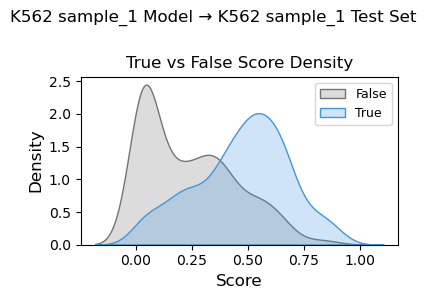

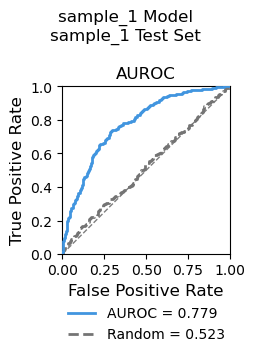

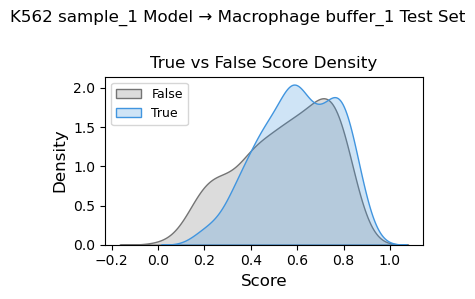

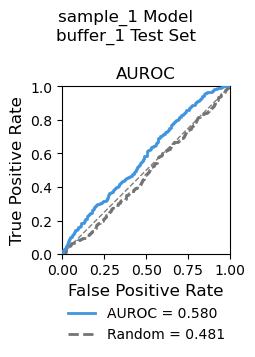

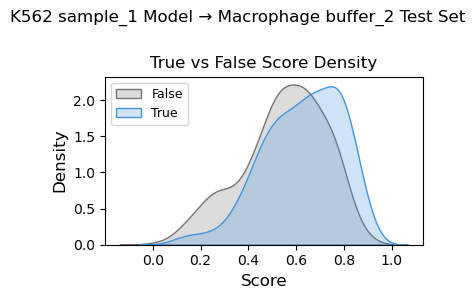

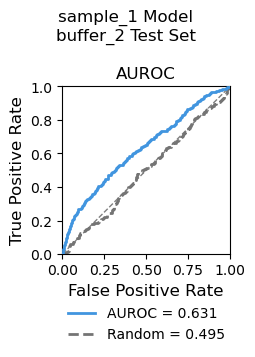

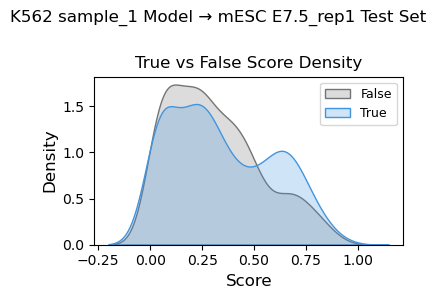

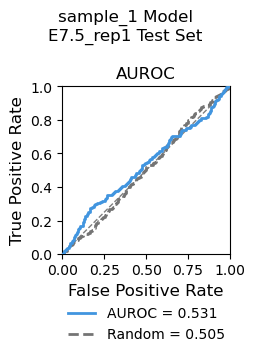

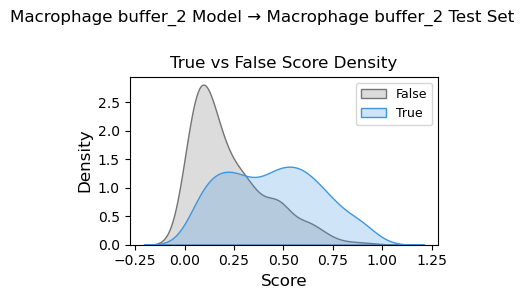

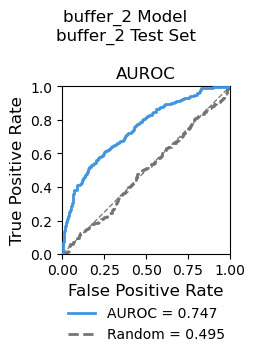

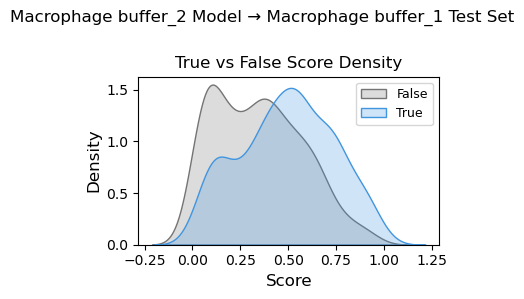

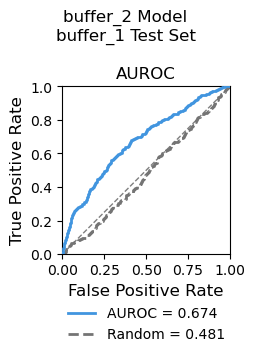

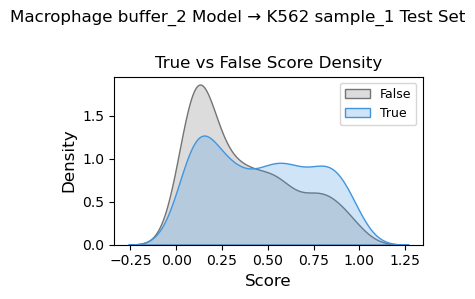

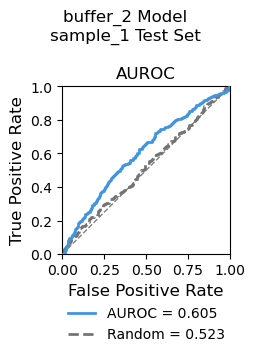

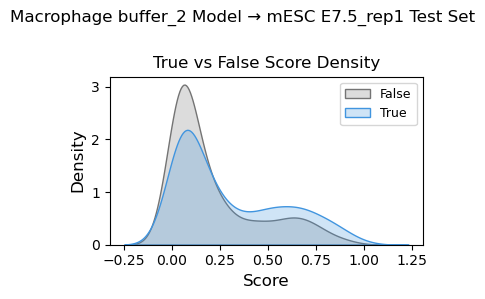

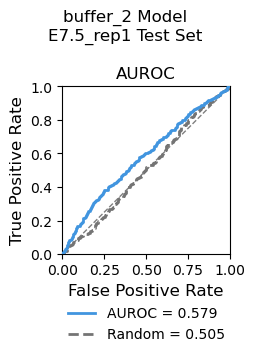

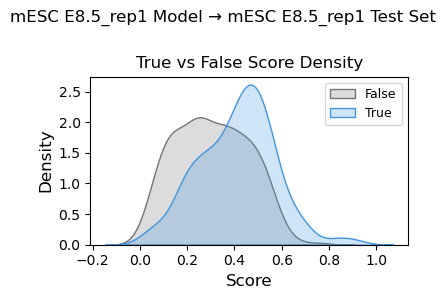

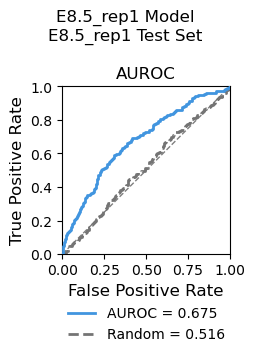

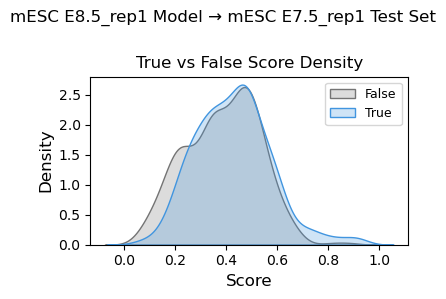

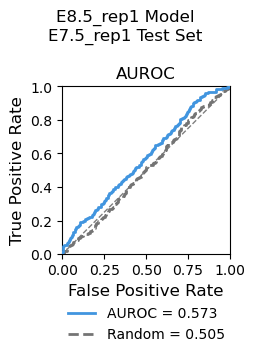

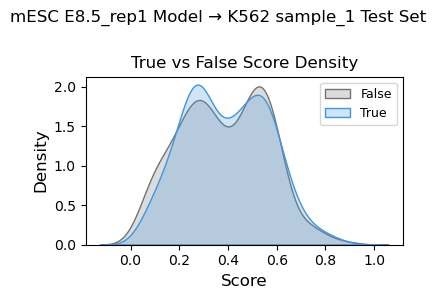

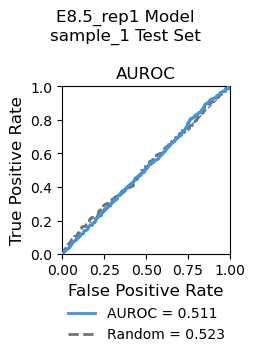

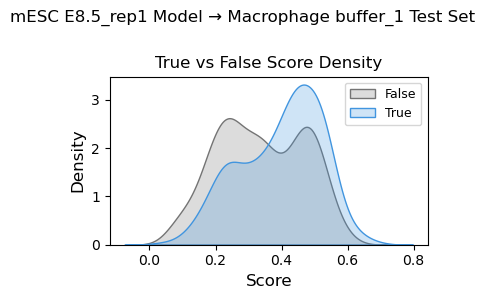

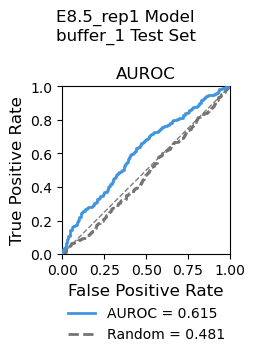

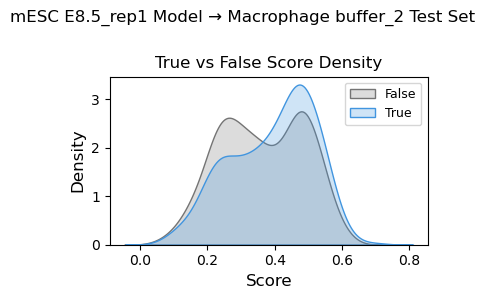

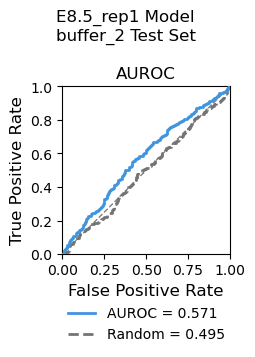

In [12]:
for title in all_plot_data.keys():
    all_labels_flat = all_plot_data[title][0]
    all_scores_flat = all_plot_data[title][1]
    
    histogram_fig = plotting_utils.plot_score_histograms(
        labels=all_labels_flat,
        scores=all_scores_flat,
        n_bins=50,
        y_log=False,
        panel_kind="kde",
        density=False,
        title = title
    )
    histogram_fig.show()
    
    model_sample, test_set_sample = title.split(" → ")
    model_sample = model_sample.split("Model")[0].split()[1].strip()
    test_set_sample = test_set_sample.split("Test Set")[0].split()[1].strip()
    title = f"{model_sample} Model\n{test_set_sample} Test Set"

    auroc_auprc_fig = plotting_utils.plot_auroc_auprc(
        labels=all_labels_flat,
        scores=all_scores_flat,
        title = title,
        plot_type = "roc"
    )
    auroc_auprc_fig.show()

### Generalizability

In [ ]:
generalizability_df = pd.read_csv(RESULT_DIR / "model_generalizability_results.csv")
display(generalizability_df.T)

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
Model,E7.5_rep1,E8.5_rep1,E7.5_rep1,E8.5_rep1,E7.5_rep1,E7.5_rep1,E8.5_rep1,E8.5_rep1,E7.5_rep1,E7.5_rep1,...,buffer_1,buffer_2,buffer_1,buffer_1,buffer_2,buffer_2,buffer_1,buffer_1,buffer_2,buffer_2
Test Set,E7.5_rep1,E8.5_rep1,E8.5_rep1,E7.5_rep1,hepatocytes_1,hepatocytes_3,hepatocytes_1,hepatocytes_3,buffer_1,buffer_2,...,buffer_1,buffer_2,E7.5_rep1,E8.5_rep1,E7.5_rep1,E8.5_rep1,hepatocytes_1,hepatocytes_3,hepatocytes_1,hepatocytes_3
auroc,0.695603,0.681928,0.578491,0.595676,0.674138,0.624697,0.634848,0.64531,0.572732,0.593382,...,0.672208,0.723021,0.522451,0.495177,0.554182,0.517615,0.612119,0.590208,0.534306,0.516186
auprc,0.607597,0.493422,0.385816,0.529818,0.553219,0.480059,0.502604,0.516265,0.403247,0.454181,...,0.488757,0.601141,0.467505,0.313747,0.493197,0.332119,0.503108,0.497231,0.422218,0.427734
accuracy,0.623,0.708,0.6925,0.5975,0.5785,0.552,0.579,0.5775,0.6605,0.6315,...,0.5685,0.6865,0.5385,0.6305,0.5795,0.646,0.581,0.579,0.5545,0.566
precision,0.669492,0.550173,0.489362,0.539295,0.714286,0.173913,0.507519,0.510638,0.384615,0.0,...,0.42123,0.653631,0.446579,0.323034,0.493069,0.313725,0.529851,0.532847,0.28972,0.376812
early_precision,0.669492,0.550173,0.489362,0.539295,0.714286,0.173913,0.507519,0.510638,0.384615,0.0,...,0.42123,0.653631,0.446579,0.323034,0.493069,0.313725,0.529851,0.532847,0.28972,0.376812
recall,0.189448,0.25938,0.075041,0.238609,0.00591,0.014101,0.159574,0.169213,0.007396,0.0,...,0.739645,0.317503,0.446043,0.187602,0.298561,0.130506,0.083924,0.085781,0.036643,0.030552
f1,0.295327,0.35255,0.130127,0.33084,0.011723,0.026087,0.242806,0.254192,0.014514,0.0,...,0.536769,0.427397,0.446311,0.237358,0.371919,0.184332,0.144898,0.147773,0.065058,0.056522
rand_auroc,0.514034,0.507281,0.506895,0.510542,0.481952,0.496221,0.491212,0.478284,0.503223,0.493285,...,0.51142,0.500392,0.523464,0.470626,0.52093,0.473438,0.481925,0.497871,0.499572,0.514595


In [ ]:
org_dict = {
    "E7.5_rep1": ("mouse", "mESC"),
    "E8.5_rep1": ("mouse", "mESC"),
    "buffer_1": ("human", "Macrophage"),
    "buffer_2": ("human", "Macrophage"),
    "hepatocytes_1": ("mouse", "mouse_hepatocytes"),
    "hepatocytes_3": ("mouse", "mouse_hepatocytes"),
    "liver_1": ("mouse", "mouse_liver"),
    "liver_3": ("mouse", "mouse_liver"),
    "sample_1": ("human", "K562"),
    "WT_D13_rep1": ("human", "iPSC")
}
generalizability_df["Model Organism"] = generalizability_df["Model"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[0])
generalizability_df["Model Cell Type"] = generalizability_df["Model"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[1])
generalizability_df["Test Set Organism"] = generalizability_df["Test Set"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[0])
generalizability_df["Test Set Cell Type"] = generalizability_df["Test Set"].map(lambda x: org_dict.get(x, ("Unknown", "Unknown"))[1])

generalizability_df["auprc_lift"] = generalizability_df["auprc"] - generalizability_df["rand_auprc"]

own_test_set = generalizability_df[generalizability_df["Model"] == generalizability_df["Test Set"]]
same_cell_type = generalizability_df[(generalizability_df["Model Cell Type"] == generalizability_df["Test Set Cell Type"]) & (generalizability_df["Model"] != generalizability_df["Test Set"])]
different_cell_type = generalizability_df[(generalizability_df["Model Cell Type"] != generalizability_df["Test Set Cell Type"]) & (generalizability_df["Model Organism"] == generalizability_df["Test Set Organism"])]
different_organism = generalizability_df[generalizability_df["Model Organism"] != generalizability_df["Test Set Organism"]]

def agg_results(df):
    return df.groupby(["Model Cell Type"]).agg(
        auroc_mean=("auroc", "mean"),
        auprc_mean=("auprc", "mean"),
        auprc_lift_mean=("auprc_lift", "mean"),
        accuracy_mean=("accuracy", "mean"),
        precision_mean=("precision", "mean"),
        early_precision_mean=("early_precision", "mean"),
        recall_mean=("recall", "mean"),
        f1_mean=("f1", "mean")
    ).reset_index()
    

own_test_set_group = agg_results(own_test_set)
same_cell_type_group = agg_results(same_cell_type)
different_cell_type_group = agg_results(different_cell_type)
different_organism_group = agg_results(different_organism)

In [46]:
different_organism_group

,Model Cell Type,auroc_mean,auprc_mean,auprc_lift_mean,accuracy_mean,precision_mean,early_precision_mean,recall_mean,f1_mean
0,Macrophage,0.542780,0.432107,0.040643,0.584375,0.413204,0.413204,0.162452,0.206771
1,mESC,0.592198,0.435253,0.082807,0.645250,0.341284,0.341284,0.071054,0.110777
2,mouse_hepatocytes,0.449081,0.337574,-0.025224,0.581750,0.321230,0.321230,0.135916,0.185594


In [53]:
importlib.reload(plotting_utils)

<module 'plotting_utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/plotting_utils.py'>

In [ ]:
# histogram_fig = plotting_utils.plot_score_histograms(
#     labels=labels,
#     scores=scores,
#     n_bins=50,
#     y_log=False,
#     panel_kind="kde",
#     density=False,
#     # title = title
# )
# histogram_fig.show()

In [30]:
importlib.reload(plotting_utils)

<module 'plotting_utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/plotting_utils.py'>

In [ ]:
gt_df_list = config.gt_by_dataset_dict["mESC"]

unique_tfs = set()
unique_tgs = set()

for gt_file in gt_df_list:
    gt_df = utils.load_ground_truth(gt_file)
    print(f"Ground truth file: {gt_file}")
    
    gt_tfs = gt_df["Source"].unique()
    gt_tgs = gt_df["Target"].unique()
    print(f"  - Unique TFs: {len(gt_tfs)}")
    print(f"  - Unique TGs: {len(gt_tgs)}")
    
    unique_tfs.update(gt_tfs)
    unique_tgs.update(gt_tgs)

print(f"Total unique TFs across all ground truth files: {len(unique_tfs)}")
print(f"Total unique TGs across all ground truth files: {len(unique_tgs)}")

INFO - Loading ground truth file: chip_atlas_tf_peak_tg_dist.csv


Ground truth file: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/ground_truth_files/chip_atlas_tf_peak_tg_dist.csv


INFO - Loading ground truth file: RN111.tsv


  - Unique TFs: 131
  - Unique TGs: 24821


INFO - Loading ground truth file: RN112.tsv


Ground truth file: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/ground_truth_files/RN111.tsv
  - Unique TFs: 247
  - Unique TGs: 25692


INFO - Loading ground truth file: RN114.tsv


Ground truth file: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/ground_truth_files/RN112.tsv
  - Unique TFs: 55
  - Unique TGs: 16522


INFO - Loading ground truth file: RN116.tsv


Ground truth file: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/ground_truth_files/RN114.tsv
  - Unique TFs: 47
  - Unique TGs: 21240
Ground truth file: /gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data/ground_truth_files/RN116.tsv
  - Unique TFs: 21
  - Unique TGs: 4542
Total unique TFs across all ground truth files: 362
Total unique TGs across all ground truth files: 34326


In [37]:
importlib.reload(utils)

<module 'utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/utils.py'>

In [38]:
merged_gt_df = utils.load_ground_truth_files(gt_df_list)
print(f"Total unique TFs in merged ground truth: {merged_gt_df['Source'].nunique()}")
print(f"Total unique TGs in merged ground truth: {merged_gt_df['Target'].nunique()}")

INFO - Loading ground truth file: chip_atlas_tf_peak_tg_dist.csv
INFO - Loading ground truth file: RN111.tsv
INFO - Loading ground truth file: RN112.tsv
INFO - Loading ground truth file: RN114.tsv
INFO - Loading ground truth file: RN116.tsv


Total unique TFs in merged ground truth: 362
Total unique TGs in merged ground truth: 34326


In [39]:
# Duplicate edges in the merged ground truth
duplicate_edges = merged_gt_df[merged_gt_df.duplicated(subset=["Source", "Target"], keep=False)]
print(f"Number of duplicate edges in merged ground truth: {len(duplicate_edges)}")

Number of duplicate edges in merged ground truth: 0


In [40]:
input_data_dir = DATA_DIR / "sample_input_data" / "mESC" / "E8.5_rep1"

# Read in the ATAC and RNA pseudobulk data, and the peak-to-gene distance file
atac_pseudobulk = pd.read_parquet(input_data_dir / "RE_pseudobulk.parquet")
peak_to_gene_distance = pd.read_parquet(input_data_dir / "peak_to_gene_dist.parquet")
rna_pseudobulk = pd.read_parquet(input_data_dir / "TG_pseudobulk.parquet")

logging.info(f"ATAC peaks BEFORE peak-to-gene filtering: {atac_pseudobulk.shape[0]:,}")
# Keep only ATAC peaks that are present in the peak-to-gene distance table
valid_peak_ids = set(peak_to_gene_distance["peak_id"])

atac_pseudobulk = atac_pseudobulk.loc[
    atac_pseudobulk.index.isin(valid_peak_ids)
].copy()
logging.info(f"ATAC peaks AFTER peak-to-gene filtering: {atac_pseudobulk.shape[0]:,}")

rna_pseudobulk_norm = rna_pseudobulk.copy()
rna_pseudobulk_norm.index = rna_pseudobulk_norm.index.str.upper()

common_cells = sorted(set(rna_pseudobulk_norm.columns) & set(atac_pseudobulk.columns))

if len(common_cells) == 0:
    raise ValueError(
        "No common pseudobulk cell columns between RNA and ATAC matrices."
    )

logging.info(f"Common RNA/ATAC pseudobulk columns: {len(common_cells):,}")

INFO - ATAC peaks BEFORE peak-to-gene filtering: 224,116
INFO - ATAC peaks AFTER peak-to-gene filtering: 221,047
INFO - Common RNA/ATAC pseudobulk columns: 2,901


In [ ]:
tf_name_to_idx_cache_path = config.tf_name_to_idx_cache_path

merged_ground_truth_df = merged_gt_df.copy()
peak_to_gene = peak_to_gene_distance.copy()
peak_to_gene["target_id_norm"] = peak_to_gene["target_id"].str.upper()

merged_ground_truth_df["Source"] = merged_ground_truth_df["Source"].str.upper()
merged_ground_truth_df["Target"] = merged_ground_truth_df["Target"].str.upper()

gt_tfs_in_rna = set(merged_ground_truth_df["Source"]).intersection(rna_pseudobulk_norm.index)
gt_tgs_in_rna = set(merged_ground_truth_df["Target"]).intersection(rna_pseudobulk_norm.index)
logging.info(f"Ground truth TFs in RNA pseudobulk: {len(gt_tfs_in_rna)} (Example: {list(gt_tfs_in_rna)[:5]})")
logging.info(f"Ground truth TGs in RNA pseudobulk: {len(gt_tgs_in_rna)} (Example: {list(gt_tgs_in_rna)[:5]})")

n_before_rna_filter = len(merged_ground_truth_df)

# Subset the ground truth to only TFs and TGs present in the rna_pseudobulk 
merged_ground_truth_df = merged_ground_truth_df[
    merged_ground_truth_df["Source"].isin(gt_tfs_in_rna) &
    merged_ground_truth_df["Target"].isin(gt_tgs_in_rna)
].copy()

logging.info(
    f"Ground truth edges after RNA TF/TG filtering: "
    f"{len(merged_ground_truth_df):,} / {n_before_rna_filter:,}"
)

# Get the map of TF name to index
tf_name_to_idx = pd.read_csv(tf_name_to_idx_cache_path)
tf_name_to_idx["tf_name"] = tf_name_to_idx["tf_name"].str.upper()
tf_name_to_idx = tf_name_to_idx.set_index("tf_name")["tf_idx"].to_dict()

# Only keep ground truth TFs that have embeddings (i.e. were present in the TF-DNA model training data)
gt_tfs_in_embeddings = set(tf_name_to_idx.keys()).intersection(gt_tfs_in_rna)
logging.info(f"Ground truth TFs with embeddings: {len(gt_tfs_in_embeddings)} (Example: {list(gt_tfs_in_embeddings)[:5]})")

n_before_tf_embedding_filter = len(merged_ground_truth_df)

merged_ground_truth_df = merged_ground_truth_df[
    merged_ground_truth_df["Source"].isin(gt_tfs_in_embeddings)
].copy()

logging.info(
    f"Ground truth edges after filtering to TFs with embeddings: "
    f"{len(merged_ground_truth_df):,} / {n_before_tf_embedding_filter:,}"
)

INFO - Ground truth TFs in RNA pseudobulk: 348 (Example: ['SAP130', 'NANOG', 'GATA6', 'SMC1A', 'PYGO2'])
INFO - Ground truth TGs in RNA pseudobulk: 18972 (Example: ['CPN2', 'GNG13', 'NDUFB2', 'OLFR775', 'PDHA1'])
INFO - Ground truth edges after RNA TF/TG filtering: 6,834,193 / 8,927,453
INFO - Ground truth TFs with embeddings: 158 (Example: ['NANOG', 'ZBTB2', 'TCF7', 'GATA6', 'HNF4A'])
INFO - Ground truth edges after filtering to TFs with embeddings: 5,080,549 / 6,834,193


In [29]:
gt_tfs = set(merged_ground_truth_df["Source"])
gt_tgs = set(merged_ground_truth_df["Target"])

print(f"After filtering, there are {len(gt_tfs)} unique TFs and {len(gt_tgs)} unique TGs in the ground truth.")

After filtering, there are 158 unique TFs and 18953 unique TGs in the ground truth.


In [34]:
import itertools

merged_ground_truth_df = merged_ground_truth_df.drop_duplicates(subset=["Source", "Target"]).reset_index(drop=True)
# Get the number of all possible TF-TG pairs in the ground truth
num_possible_pairs = len(gt_tfs) * len(gt_tgs)
print(f"Total possible TF-TG pairs in the ground truth: {num_possible_pairs:,}")

print(f"True interactions: {len(merged_ground_truth_df):,}")
print(f"Possible false interactions: {num_possible_pairs - len(merged_ground_truth_df):,}")

Total possible TF-TG pairs in the ground truth: 2,994,574
True interactions: 793,919
Possible false interactions: 2,200,655


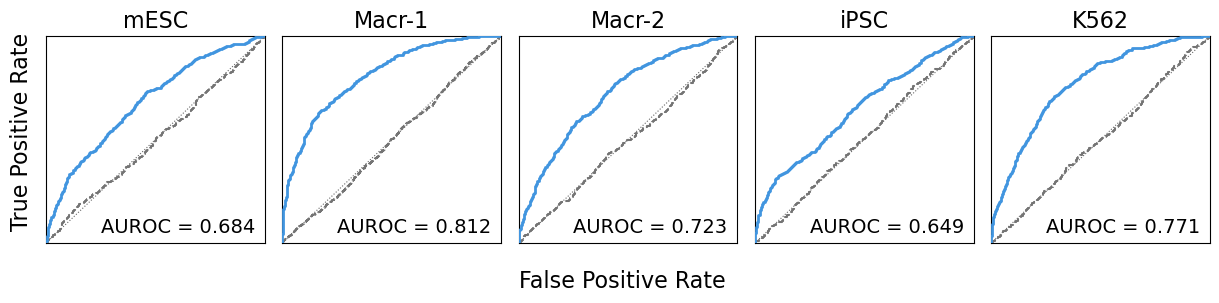

In [ ]:
models_to_plot = ["E7.5_rep1", "buffer_1", "buffer_2", "WT_D13_rep1", "sample_1"]

sample_to_title_map = {
    "E7.5_rep1": "mESC",
    "buffer_1": "Macr-1",
    "buffer_2": "Macr-2",
    "WT_D13_rep1": "iPSC",
    "sample_1": "K562"
}

combined_fig, combined_axes = plt.subplots(
    nrows=1,
    ncols=len(models_to_plot),
    figsize=(12, 3),
    sharex=True,
    sharey=True,
)

roc_line_color = "#4195df"
rand_line_color = "#747474"

for ax, selected_model in zip(combined_axes, models_to_plot):

    matching_titles = [
        title for title in all_plot_data.keys()
        if f"{selected_model} Model" in title and f"{selected_model} Test Set" in title
    ]

    if len(matching_titles) == 0:
        ax.axis("off")
        ax.set_title(f"{selected_model}\nMissing", fontsize=10)
        continue

    title = matching_titles[0]

    labels = all_plot_data[title][0]
    scores = all_plot_data[title][1]

    labels = np.asarray(labels).astype(int).ravel()
    scores = np.asarray(scores).astype(float).ravel()

    fpr, tpr, _ = roc_curve(labels, scores)
    auroc = roc_auc_score(labels, scores)

    rand_scores = plotting_utils._create_random_distribution(scores)
    rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)
    rand_auroc = roc_auc_score(labels, rand_scores)

    ax.plot(
        fpr,
        tpr,
        lw=2,
        color=roc_line_color,
        label=f"AUROC = {auroc:.3f}",
        zorder=3,
    )

    ax.plot(
        rand_fpr,
        rand_tpr,
        color=rand_line_color,
        linestyle="--",
        lw=1.5,
        label=f"Random = {rand_auroc:.3f}",
        zorder=2,
    )

    ax.plot(
        [0, 1],
        [0, 1],
        color="black",
        linestyle=":",
        lw=0.8,
        alpha=0.6,
        zorder=1,
    )

    ax.set_title(sample_to_title_map.get(selected_model, selected_model), fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.text(
        0.25,
        0.05,
        f"AUROC = {auroc:.3f}",
        transform=ax.transAxes,
        fontsize=14,
        bbox=dict(facecolor="none", edgecolor="none"),
    )

    ax.tick_params(bottom=False, left=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# combined_fig.suptitle("Model vs Test Set", fontsize=14, y=1.05)

combined_fig.text(
    0.5,
    -0.02,
    "False Positive Rate",
    ha="center",
    fontsize=16,
)

combined_fig.text(
    -0.01,
    0.5,
    "True Positive Rate",
    va="center",
    rotation="vertical",
    fontsize=16,
)

combined_fig.subplots_adjust(
    left=0.02,
    right=0.99,
    bottom=0.13,
    top=0.82,
    wspace=0.08,
)

plt.show()

combined_fig.savefig(all_evaluation_plot_dir / f"models_vs_own_test_set.png", dpi=300, bbox_inches="tight")

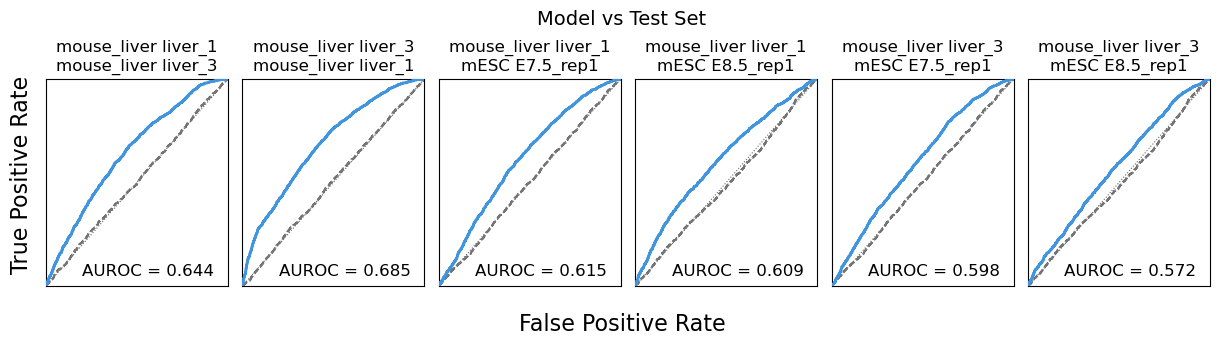

In [29]:
comparisons = [title for title in all_plot_data.keys()]

combined_fig, combined_axes = plt.subplots(
    nrows=1,
    ncols=len(comparisons),
    figsize=(12, 3),
    sharex=True,
    sharey=True,
)

roc_line_color = "#4195df"
rand_line_color = "#747474"

for ax, title in zip(combined_axes, comparisons):

    model_name = title.split(" Model")[0]
    test_set_name = title.split("→")[1].split("Test Set")[0].strip()
    
    labels = all_plot_data[title][0]
    scores = all_plot_data[title][1]

    labels = np.asarray(labels).astype(int).ravel()
    scores = np.asarray(scores).astype(float).ravel()

    fpr, tpr, _ = roc_curve(labels, scores)
    auroc = roc_auc_score(labels, scores)

    rand_scores = plotting_utils._create_random_distribution(scores)
    rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)
    rand_auroc = roc_auc_score(labels, rand_scores)

    ax.plot(
        fpr,
        tpr,
        lw=2,
        color=roc_line_color,
        label=f"AUROC = {auroc:.3f}",
        zorder=3,
    )

    ax.plot(
        rand_fpr,
        rand_tpr,
        color=rand_line_color,
        linestyle="--",
        lw=1.5,
        label=f"Random = {rand_auroc:.3f}",
        zorder=2,
    )

    ax.plot(
        [0, 1],
        [0, 1],
        color="black",
        linestyle=":",
        lw=0.8,
        alpha=0.6,
        zorder=1,
    )

    ax.set_title(f"{model_name}\n{test_set_name}", fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.text(
        0.2,
        0.05,
        f"AUROC = {auroc:.3f}",
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(facecolor="none", edgecolor="none"),
    )

    ax.tick_params(bottom=False, left=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

combined_fig.suptitle("Model vs Test Set", fontsize=14, y=1.05)

combined_fig.text(
    0.5,
    -0.02,
    "False Positive Rate",
    ha="center",
    fontsize=16,
)

combined_fig.text(
    -0.01,
    0.5,
    "True Positive Rate",
    va="center",
    rotation="vertical",
    fontsize=16,
)

combined_fig.subplots_adjust(
    left=0.02,
    right=0.99,
    bottom=0.13,
    top=0.82,
    wspace=0.08,
)

plt.show()

# combined_fig.savefig(all_evaluation_plot_dir / f"models_vs_own_test_set.png", dpi=300, bbox_inches="tight")

### ROC - All models vs all test sets

In [134]:
model_samples = [
    "E7.5_rep1",
    "E7.5_rep2",
    "E8.5_rep1",
    "E8.5_rep2",
    "WT_D13_rep1",
    "buffer_1",
    "buffer_2",
    "buffer_3",
    "buffer_4",
    "sample_1",
]

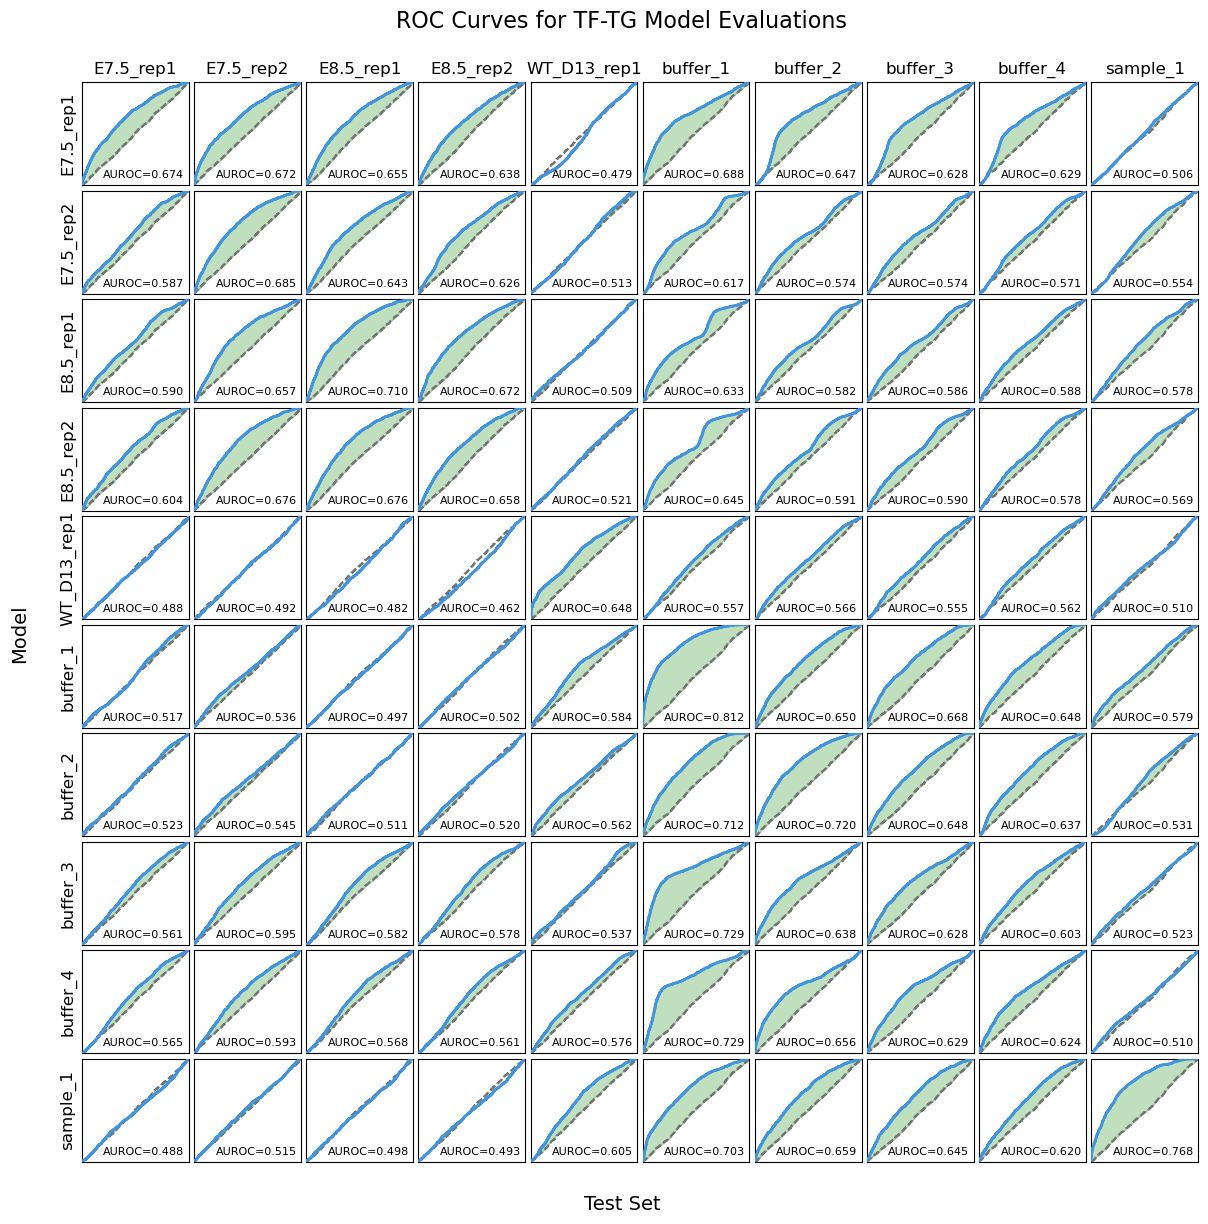

In [135]:
fig, axes = plt.subplots(
    nrows=len(model_samples),
    ncols=len(model_samples),
    figsize=(12, 12),
    sharex=True,
    sharey=True,
)

for i, model_sample in enumerate(model_samples):
    for j, test_sample in enumerate(model_samples):

        ax = axes[i, j]

        matching_titles = [
            key for key in all_plot_data
            if f"{model_sample} Model" in key and f"{test_sample} Test Set" in key
        ]

        if len(matching_titles) == 0:
            ax.axis("off")
            continue

        title = matching_titles[0]

        if title not in all_plot_data:
            ax.axis("off")
            ax.set_title("Missing", fontsize=8)
            continue

        labels = all_plot_data[title][0]
        scores = all_plot_data[title][1]

        labels = np.asarray(labels).astype(int).ravel()
        scores = np.asarray(scores).astype(float).ravel()

        fpr, tpr, _ = roc_curve(labels, scores)
        auroc = roc_auc_score(labels, scores)

        rand_scores = plotting_utils._create_random_distribution(scores)
        rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)

        ax.plot(
            fpr,
            tpr,
            lw=2,
            color="#4195df",
            zorder=3,
        )

        ax.plot(
            rand_fpr,
            rand_tpr,
            color="#747474",
            linestyle="--",
            lw=1.5,
            zorder=2,
        )
        
        # Interpolate random TPR onto model FPR grid
        rand_tpr_interp = np.interp(fpr, rand_fpr, rand_tpr)

        # Fill only where model ROC is above random ROC
        ax.fill_between(
            fpr,
            tpr,
            rand_tpr_interp,
            where=(tpr > rand_tpr_interp),
            interpolate=True,
            color="green",
            alpha=0.25,
            zorder=1,
        )

        # ax.plot(
        #     [0, 1],
        #     [0, 1],
        #     color="black",
        #     linestyle=":",
        #     lw=0.8,
        #     zorder=1,
        # )

        ax.text(
            0.20,
            0.07,
            f"AUROC={auroc:.3f}",
            transform=ax.transAxes,
            fontsize=8,
            bbox=dict(facecolor="none", edgecolor="none"),
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.tick_params(bottom=False, left=False, right=False)

        if i == 0:
            ax.set_title(test_sample, fontsize=12, ha="center")

        if j == 0:
            ax.set_ylabel(model_sample, fontsize=12)
            ax.set_yticks([])

        if i == len(model_samples) - 1:
            ax.set_xlabel("")
            ax.set_xticks([])

fig.suptitle("ROC Curves for TF-TG Model Evaluations", fontsize=16, y=1.02)

fig.text(
    0.5,
    0.02,
    "Test Set",
    ha="center",
    fontsize=14,
)

fig.text(
    -0.01,
    0.5,
    "Model",
    va="center",
    rotation="vertical",
    fontsize=14,
)

fig.subplots_adjust(
    left=0.05,
    right=0.98,
    bottom=0.06,
    top=0.96,
    wspace=0.05,
    hspace=0.05,
)
plt.show()

fig.savefig(all_evaluation_plot_dir / "model_vs_test_set_roc_curves.png", dpi=300, bbox_inches="tight")


### PRC - All models vs all test sets

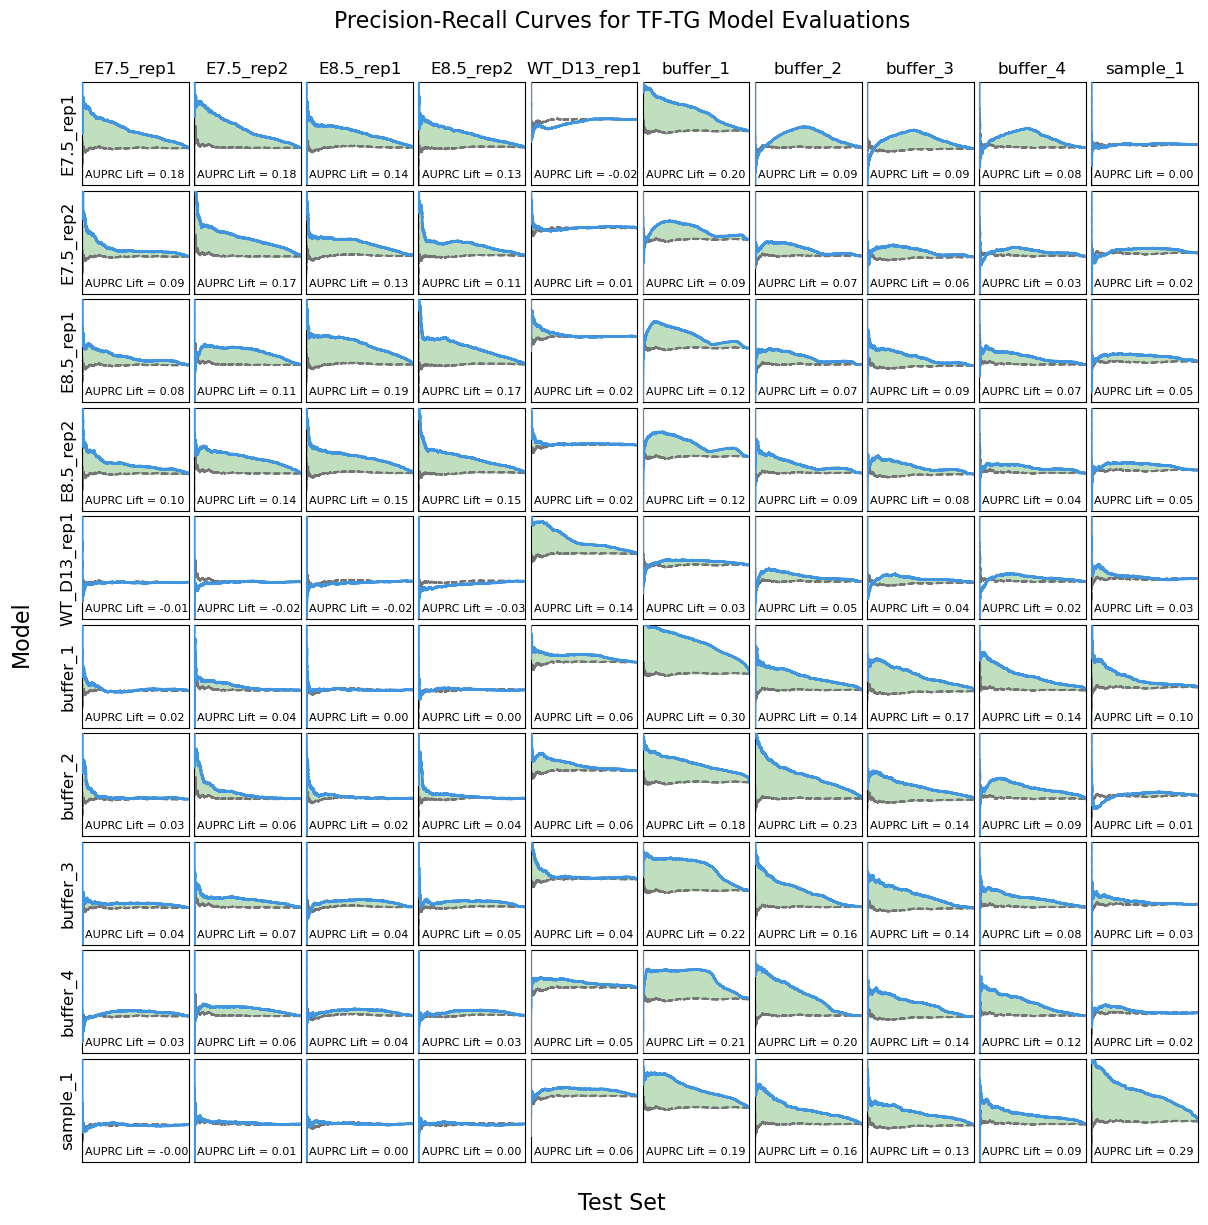

In [138]:
fig, axes = plt.subplots(
    nrows=len(model_samples),
    ncols=len(model_samples),
    figsize=(12, 12),
    sharex=True,
    sharey=True,
)

for i, model_sample in enumerate(model_samples):
    for j, test_sample in enumerate(model_samples):

        ax = axes[i, j]

        matching_titles = [
            key for key in all_plot_data
            if f"{model_sample} Model" in key and f"{test_sample} Test Set" in key
        ]

        if len(matching_titles) == 0:
            ax.axis("off")
            continue

        title = matching_titles[0]

        if title not in all_plot_data:
            ax.axis("off")
            ax.set_title("Missing", fontsize=8)
            continue

        labels = all_plot_data[title][0]
        scores = all_plot_data[title][1]

        labels = np.asarray(labels).astype(int).ravel()
        scores = np.asarray(scores).astype(float).ravel()
        
        prec, rec, _ = precision_recall_curve(labels, scores)
        auprc = average_precision_score(labels, scores)

        rand_prec, rand_rec, _ = precision_recall_curve(labels, rand_scores)
        rand_auprc = average_precision_score(labels, rand_scores)
        
        auprc_lift = auprc - rand_auprc
        
        order = np.argsort(rand_rec)
        rand_rec_sorted = rand_rec[order]
        rand_prec_sorted = rand_prec[order]

        ax.plot(
            rec,
            prec,
            lw=2,
            color="#4195df",
            zorder=3,
        )

        ax.plot(
            rand_rec,
            rand_prec,
            color="#747474",
            linestyle="--",
            lw=1.5,
            zorder=2,
        )
        
        # Interpolate random recall onto model grid
        rand_prec_interp = np.interp(rec, rand_rec_sorted, rand_prec_sorted)

        # Fill only where model AUPRC is above random AUPRC
        ax.fill_between(
            rec,
            prec,
            rand_prec_interp,
            where=(prec > rand_prec_interp),
            interpolate=True,
            color="green",
            alpha=0.25,
            zorder=1,
        )

        # ax.plot(
        #     [0, 1],
        #     [0, 1],
        #     color="black",
        #     linestyle=":",
        #     lw=0.8,
        #     zorder=1,
        # )

        ax.text(
            0.03,
            0.07,
            f"AUPRC Lift = {auprc_lift:.2f}",
            transform=ax.transAxes,
            fontsize=8,
            bbox=dict(facecolor="none", edgecolor="none"),
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.tick_params(bottom=False, left=False, right=False)

        if i == 0:
            ax.set_title(test_sample, fontsize=12, ha="center")

        if j == 0:
            ax.set_ylabel(model_sample, fontsize=12)
            ax.set_yticks([])

        if i == len(model_samples) - 1:
            ax.set_xlabel("")
            ax.set_xticks([])

fig.suptitle("Precision-Recall Curves for TF-TG Model Evaluations", fontsize=16, y=1.02)

fig.text(
    0.5,
    0.02,
    "Test Set",
    ha="center",
    fontsize=16,
)

fig.text(
    -0.01,
    0.5,
    "Model",
    va="center",
    rotation="vertical",
    fontsize=16,
)

fig.subplots_adjust(
    left=0.05,
    right=0.98,
    bottom=0.06,
    top=0.96,
    wspace=0.05,
    hspace=0.05,
)
plt.show()

fig.savefig(all_evaluation_plot_dir / "model_vs_test_set_pr_curves.png", dpi=300, bbox_inches="tight")


### Evaluation metrics

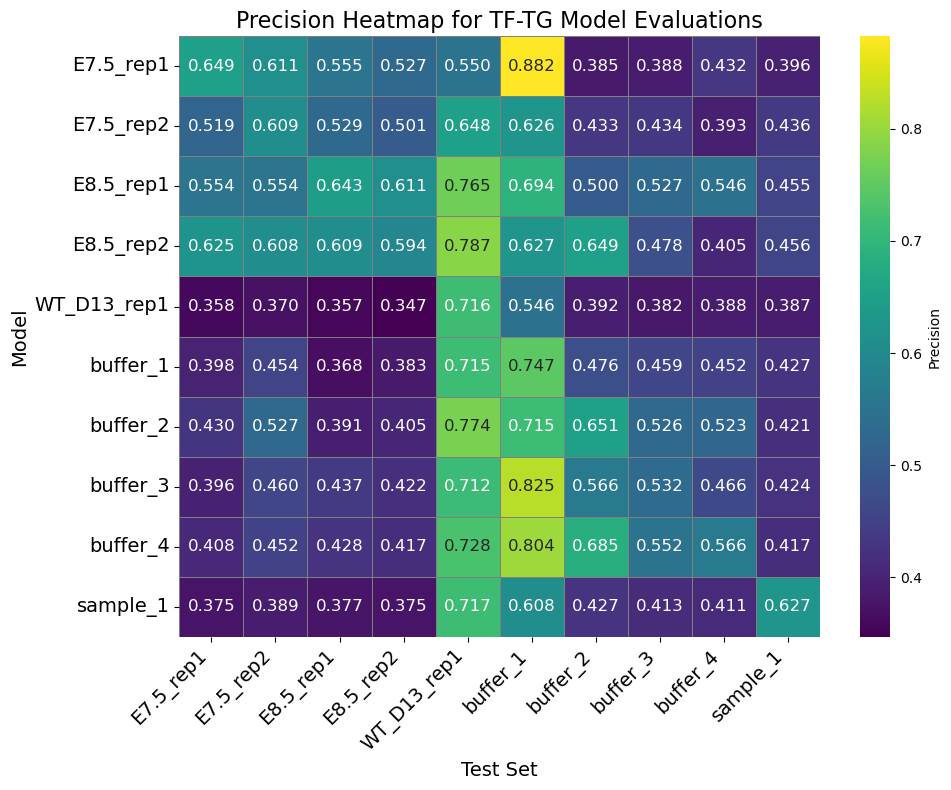

In [148]:
# Heatmap of AUROC values for each model vs test set combination
selected_metric = "Precision"
test_comparison_df = full_comparison_df.copy()

test_comparison_df["AUPRC Lift"] = test_comparison_df["auprc"] - test_comparison_df["rand_auprc"]
test_comparison_df = test_comparison_df.rename(columns={
    "auroc": "AUROC", 
    "auprc": "AUPRC",
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    })

test_comparison_df = test_comparison_df[["Model", "Test Set", selected_metric]]

test_comparison_df_pivot = test_comparison_df.pivot(index="Model", columns="Test Set", values=selected_metric)

fig = plt.figure(figsize=(10, 8))
heatmap_fig = sns.heatmap(
    test_comparison_df_pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    cbar_kws={'label': selected_metric},
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 12}
)
heatmap_fig.set_title(f"{selected_metric} Heatmap for TF-TG Model Evaluations", fontsize=16)
heatmap_fig.set_xlabel("Test Set", fontsize=14)
heatmap_fig.set_ylabel("Model", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0, fontsize=14)
plt.tight_layout()
plt.show()

fig.savefig(all_evaluation_plot_dir / f"model_vs_test_set_{selected_metric.lower().replace(' ', '_')}_heatmap.png", dpi=300, bbox_inches="tight")

## Model data shapes

In [ ]:
evaluation_cell_type = "mESC"
model_training_sample = "E7.5_rep1"
evaluation_sample = "E7.5_rep1"

print(f"Model {model_training_sample} | Test set {evaluation_sample}")

tf_tg_model_chkpt = tf_tg_model_checkpoints[evaluation_cell_type][model_training_sample]
tf_dna_model_chkpt = config.tf_dna_model_checkpoints[evaluation_cell_type]

# print(f"Loading TF→TG model")
dataset_split_type = "test"
subset_size = 5000

cell_type_cache_dir = DATA_DIR / f"{evaluation_cell_type}_cache"

# print(f"Loading cached dataset with subset size: {subset_size}")
data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = utils.load_training_cache_dataset(
    sample_name=evaluation_sample,
    cell_type_cache_dir=cell_type_cache_dir,
    split_type=dataset_split_type,
    subset_size=subset_size
    )

tf_tg_model = utils.load_tf_tg_regulation_model(tf_dna_model_chkpt, tf_tg_model_chkpt, tf_embeddings_tensor, tf_mask_tensor)

# print("Moving model to device")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = tf_tg_model.model

Model E7.5_rep1 | Test set E7.5_rep1


In [ ]:
def shape_of(x):
    if torch.is_tensor(x):
        return tuple(x.shape)
    if isinstance(x, dict):
        return {k: shape_of(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [shape_of(v) for v in x]
    if x is None:
        return None
    return type(x).__name__


def make_shape_hook(name):
    def hook(module, args, kwargs, output):
        print(f"\n{name}")
        print(f"  args  : {shape_of(args)}")
        print(f"  module: {type(module).__name__}")
        print(f"  kwargs: {shape_of(kwargs)}")
        print(f"  output: {shape_of(output)}")
    return hook


model = tf_tg_model.model.to(device)
model.eval()

hook_names = {
    "tf_peak_model.tf_encoder",
    "tf_peak_model.peak_encoder",
    "tf_peak_model.cross_attn",
    "tf_peak_model.classifier",
    "peak_feature_proj",
    "tf_expr_proj",
    "tg_expr_proj",
    "tg_query_proj",
    "peak_attention",
    "norm",
    "classifier",
}

# Clear old hooks aggressively in notebook debugging
for module in model.modules():
    module._forward_hooks.clear()
    module._forward_pre_hooks.clear()
    module._backward_hooks.clear()

hooks = []
for name, module in model.named_modules():
    if name in hook_names:
        hooks.append(
            module.register_forward_hook(
                make_shape_hook(name),
                with_kwargs=True,
            )
        )
        
batch = next(iter(data_loader))
batch = tf_to_tg_module.move_batch_to_device(batch, device)

print("\nBatch input shapes:")
for k, v in batch.items():
    if torch.is_tensor(v):
        print(f"  {k}: {tuple(v.shape)}")

with torch.no_grad():
    edge_logits, aux_outputs = model(
        tf_embedding=batch["tf_embedding"],
        tf_mask=batch["tf_mask"],
        peak_sequences=batch["peak_sequences"],
        peak_accessibility=batch["peak_accessibility"],
        peak_distance=batch["peak_distance"],
        tf_expression=batch["tf_expression"],
        tg_expression=batch["tg_expression"],
        peak_mask=batch.get("peak_mask", None),
        cell_mask=batch["cell_mask"],
        pooling_mode="lse",
        pooling_temperature=1.0,
    )

print("\nFinal outputs:")
print("  edge_logits:", tuple(edge_logits.shape))
print("  aux_outputs:", shape_of(aux_outputs))

for h in hooks:
    h.remove()

## Test model performance vs other inference methods

### Functions

In [14]:
def generate_model_predictions(
    model, 
    data_loader, 
    device, 
    tf_idx_to_name, 
    tg_idx_to_name,
    compile_model=False,
    ):
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model = model.to(device)
    model.eval()
    
    if compile_model and device.type == "cuda":
        model = torch.compile(model, mode="reduce-overhead")

    tf_indices_list = []
    tg_indices_list = []
    all_scores = []

    with torch.inference_mode():
        for batch in tqdm(data_loader, desc="Evaluating", ncols=100):
            tf_indices = batch["tf_idx"].detach().cpu().numpy().ravel()
            tg_indices = batch["tg_idx"].detach().cpu().numpy().ravel()

            batch = tf_to_tg_module.move_batch_to_device(batch, device)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
                edge_logits, _ = model(
                    tf_embedding=batch["tf_embedding"],
                    tf_mask=batch["tf_mask"],
                    peak_sequences=batch["peak_sequences"],
                    peak_accessibility=batch["peak_accessibility"],
                    peak_distance=batch["peak_distance"],
                    tf_expression=batch["tf_expression"],
                    tg_expression=batch["tg_expression"],
                    peak_mask=batch.get("peak_mask", None),
                    cell_mask=batch["cell_mask"],
                    pooling_mode=pooling_mode,
                    pooling_temperature=pooling_temperature,
                )

            scores = torch.sigmoid(edge_logits.float())

            tf_indices_list.append(tf_indices)
            tg_indices_list.append(tg_indices)
            all_scores.append(scores.detach().cpu().numpy().ravel())

    all_tf_indices_flat = np.concatenate(tf_indices_list)
    all_tg_indices_flat = np.concatenate(tg_indices_list)
    all_scores_flat = np.concatenate(all_scores)

    tf_names = [tf_idx_to_name[int(idx)].capitalize() for idx in all_tf_indices_flat]
    tg_names = [tg_idx_to_name[int(idx)].capitalize() for idx in all_tg_indices_flat]

    prediction_df = pd.DataFrame({
        "Source": tf_names,
        "Target": tg_names,
        "Score": all_scores_flat,
    })

    prediction_df = (
        prediction_df.groupby(["Source", "Target"], as_index=False)["Score"]
        .median()
    )

    return prediction_df

def create_tf_tg_index_to_name_mappings(metadata):
    tf_idx_to_name = {idx: name for name, idx in metadata["tf_name_to_idx"].items()}
    tg_idx_to_name = {idx: name for name, idx in metadata["tg_id_to_idx"].items()}
    return tf_idx_to_name, tg_idx_to_name

def create_tf_tg_label_df(tftg_inputs_test):
    # Create the TF-TG label DataFrame
    tftg_inputs_test.keys()
    test_tf_input = tftg_inputs_test["tf_name"]
    test_tg_input = tftg_inputs_test["tg_name"]
    test_labels = tftg_inputs_test["label"]

    # create TF-TG label DataFrame
    tf_tg_label_df = pd.DataFrame({
        "Source": test_tf_input,
        "Target": test_tg_input,
        "Label": test_labels,
    })

    tf_tg_label_df = tf_tg_label_df.drop_duplicates(["Source", "Target"])

    gt_df: pd.DataFrame = tf_tg_label_df[tf_tg_label_df["Label"] == 1] 
    gt_tfs = set(gt_df["Source"].str.capitalize().unique()) 
    gt_targets = set(gt_df["Target"].str.capitalize().unique()) 
    gt_pairs = set(gt_df["Source"].str.capitalize() + "\t" + gt_df["Target"].str.capitalize())
    
    return tf_tg_label_df, gt_pairs, gt_tfs, gt_targets

def load_and_standardize_method(name: str, info: dict) -> pd.DataFrame:
    """
    Load a GRN CSV and rename tf_col/target_col/score_col -> Source/Target/Score.
    Extra columns are preserved.
    """
    if info["path"].suffix == ".tsv":
        sep = "\t"
    elif info["path"].suffix == ".csv":
        sep = ","
    
    df = pd.read_csv(info["path"], sep=sep, header=0, index_col=None)

    tf_col     = info["tf_col"]
    target_col = info["target_col"]
    score_col  = info["score_col"]

    rename_map = {
        tf_col: "Source",
        target_col: "Target",
        score_col: "Score",
    }

    missing = [c for c in rename_map if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing expected columns: {missing}. Got: {list(df.columns)}")

    df = df.rename(columns=rename_map)

    df = df[["Source", "Target", "Score"]]
    df["Source"] = df["Source"].astype(str).str.capitalize()
    df["Target"] = df["Target"].astype(str).str.capitalize()
    
    df["Score"] = np.abs(df["Score"])

    return df

def precision_at_k(y_true, y_score, k=10_000):
    """Compute precision at k for binary classification/ranking problems."""
    # Sort the scores in descending order and get their corresponding true labels
    top_k_indices = np.argsort(y_score)[::-1][:k]
    top_k_labels = np.array(y_true)[top_k_indices]
    
    # Calculate precision in top K
    return np.sum(top_k_labels == 1) / k

def compute_metrics(method_name: str, sample_name: str, df: pd.DataFrame, gt_pairs: set, score_threshold: float):            
    labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
    scores = df["Score"].tolist()
    
    labels = np.asarray(labels).astype(int).ravel()
    scores = np.asarray(scores).astype(float).ravel()

    preds = (scores >= score_threshold).astype(int)

    early_precision = precision_at_k(labels, scores, k=10_000)
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    if len(np.unique(labels)) < 2:
        auroc = np.nan
    else:
        auroc = roc_auc_score(labels, scores)

    return pd.DataFrame([{
        "method_name": method_name,
        "sample_name": sample_name,
        "auroc": auroc,
        "early_precision": early_precision,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "n_edges": len(labels),
        "n_pos": int(labels.sum()),
        "n_neg": int((labels == 0).sum()),
        "score_threshold": score_threshold,
    }])
    
def build_full_universe_from_gt(method_df, gt_edges, use_abs_scores=True, missing_score=0.0):
    universe_tfs = gt_edges["Source"].dropna().unique()
    universe_tgs = gt_edges["Target"].dropna().unique()

    gt_pairs = set(zip(gt_edges["Source"], gt_edges["Target"]))

    full_universe = (
        pd.MultiIndex
        .from_product([universe_tfs, universe_tgs], names=["Source", "Target"])
        .to_frame(index=False)
    )

    full_universe["_in_gt"] = [
        1 if pair in gt_pairs else 0
        for pair in zip(full_universe["Source"], full_universe["Target"])
    ]

    method_scores = method_df[["Source", "Target", "Score"]].copy()

    if use_abs_scores:
        method_scores["Score"] = method_scores["Score"].abs()

    # If method has duplicate Source-Target edges, keep strongest score
    method_scores = (
        method_scores
        .sort_values("Score", ascending=False)
        .drop_duplicates(["Source", "Target"], keep="first")
    )

    full_universe = full_universe.merge(
        method_scores,
        on=["Source", "Target"],
        how="left",
    )

    full_universe["Score"] = full_universe["Score"].fillna(missing_score)

    # print(f"Complete TF-target universe size: {len(full_universe):,}")
    # print(
    #     f"Positives in universe: {(full_universe['_in_gt'] == 1).sum():,}"
    #     f" | Negatives: {(full_universe['_in_gt'] == 0).sum():,}"
    # )

    return full_universe

### Generate predictions and load other method GRNs

In [19]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

samples_to_run = [
    # ("mESC", "E7.5_rep1"),
    # ("mESC", "E8.5_rep1"),
    # ("Macrophage", "buffer_1"),
    # ("Macrophage", "buffer_2"),
    # ("K562", "sample_1"),
    ("mouse_hepatocytes", "hepatocytes_1"),
    ("mouse_hepatocytes", "hepatocytes_3"),
]

cross_model_cell_type = "mESC"
cross_model_sample_name = "E8.5_rep1"

standardized_method_dfs = {}

label_by_method_dict = {}
score_by_method_dict = {}

metric_by_method_list = []

eval_metric_result_dir = RESULT_DIR / "evaluation_metrics"
eval_metric_result_dir.mkdir(exist_ok=True)

gt_by_sample_dict = {}

subset_size = None
for model_cell_type, sample_name in samples_to_run:
    
    logging.info(f"Processing sample: {sample_name} | Dataset: {model_cell_type}")
    
    cell_type_cache_dir = DATA_DIR / f"{model_cell_type}_cache"
    
    # Load the cached test dataset
    data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = utils.load_training_cache_dataset(
        sample_name=sample_name,
        cell_type_cache_dir=cell_type_cache_dir,
        split_type="test",
        subset_size=subset_size
        )

    # Create the TF and TG index to name mappings
    tftg_inputs_test = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / f"tftg_inputs_test.pt",
        weights_only=False,
    )

    tf_idx_to_name, tg_idx_to_name = create_tf_tg_index_to_name_mappings(metadata)

    test_set_tf_indices = list(tftg_inputs_test['tf_idx'].numpy())
    test_set_tg_indices = list(tftg_inputs_test['tg_idx'].numpy())
    
    tf_names = [tf_idx_to_name[int(idx)].capitalize() for idx in test_set_tf_indices]
    tg_names = [tg_idx_to_name[int(idx)].capitalize() for idx in test_set_tg_indices]

    cross_model_chkpt = tf_tg_model_checkpoints[cross_model_cell_type][cross_model_sample_name]
    
    tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][sample_name]
    tf_dna_model_chkpt = config.tf_dna_model_checkpoints[model_cell_type]

    # Load the TF→TG model
    tf_tg_model = utils.load_tf_tg_regulation_model(
        tf_dna_model_chkpt, 
        tf_tg_model_chkpt, 
        tf_embeddings_tensor, 
        tf_mask_tensor
        )
    
    # cross_tf_tg_model = utils.load_tf_tg_regulation_model(
    #     tf_dna_model_chkpt,
    #     cross_model_chkpt,
    #     tf_embeddings_tensor,
    #     tf_mask_tensor,
    # )

    # Generate the model predictions for the test set and create a DataFrame with TF names, TG names, and predicted scores
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    prediction_df = generate_model_predictions(tf_tg_model.model, data_loader, device, tf_idx_to_name, tg_idx_to_name, compile_model=True)
    # cross_model_prediction_df = generate_model_predictions(cross_tf_tg_model.model, data_loader, device, tf_idx_to_name, tg_idx_to_name)

    # Create the labeled ground truth DataFrame for the test set
    tf_tg_label_df, gt_pairs, gt_tfs, gt_targets = create_tf_tg_label_df(tftg_inputs_test)
    
    # Only keep TFs, TGs, and pairs that are present in both the ground truth and the method predictions to ensure fair metric computation
    gt_tfs = gt_tfs.intersection(set(tf_names))
    gt_targets = gt_targets.intersection(set(tg_names))
    gt_pairs = set(pair for pair in gt_pairs if pair.split("\t")[0] in gt_tfs and pair.split("\t")[1] in gt_targets)
    
    gt_by_sample_dict[sample_name] = (gt_pairs, gt_tfs, gt_targets)

    OTHER_METHOD_MUON_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns")

    other_method_grns = {}
    
    linger_path       = OTHER_METHOD_MUON_DIR / "LINGER_muon" / f"linger_{model_cell_type}_{sample_name}.tsv"
    scenic_plus_path  = OTHER_METHOD_MUON_DIR / "SCENIC_muon" / f"scenicplus_{model_cell_type}_{sample_name}.tsv"
    cell_oracle_path  = OTHER_METHOD_MUON_DIR / "CellOracle_muon" / f"celloracle_{model_cell_type}_{sample_name}.tsv"
    pando_path        = OTHER_METHOD_MUON_DIR / "Pando_muon" / f"pando_{model_cell_type}_{sample_name}.tsv"
    figr_path         = OTHER_METHOD_MUON_DIR / "FigR_muon" / f"figr_{model_cell_type}_{sample_name}.tsv"

    method_info = {
        "SCENIC+":    {"path": scenic_plus_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "LINGER":     {"path": linger_path,      "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "CellOracle": {"path": cell_oracle_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "Pando":      {"path": pando_path,       "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "FigR":       {"path": figr_path,        "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    }
    
    standardized_method_dfs[sample_name] = {}
    
    for method_name, info in method_info.items():
        df_std = load_and_standardize_method(method_name, info)
                
        # Filter the inferred GRN to only include edges where both the TF and TG are present in 
        # the test set ground truth
        
        mask = df_std["Source"].isin(gt_tfs) & df_std["Target"].isin(gt_targets)
        df_filtered: pd.DataFrame = df_std.loc[mask]
        
        df_filtered["Score"] = np.abs(df_filtered["Score"])
        
        # Sample the same number of edges for fair comparison
        if subset_size is not None:
            df_filtered = df_filtered.sample(n=min(df_filtered.shape[0], subset_size))
        
        standardized_method_dfs[sample_name][method_name] = df_filtered
        
    # Add the TF-TG model predictions to the standardized_method_dfs for metric computation
    standardized_method_dfs[sample_name]["MTGRN-STM"] = prediction_df
    # standardized_method_dfs[sample_name]["MTGRN-CTM"] = cross_model_prediction_df

    label_by_method_dict[sample_name] = {}
    score_by_method_dict[sample_name] = {}
    
    # Compute metrics for each method and print results
    for method_name, df in standardized_method_dfs[sample_name].items():
        labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
        scores = df["Score"].tolist()
        
        label_by_method_dict[sample_name][method_name] = labels
        score_by_method_dict[sample_name][method_name] = scores

        metrics_df = compute_metrics(method_name, sample_name, df, gt_pairs, score_threshold=0.5)
        metric_by_method_list.append(metrics_df)
        
        sample_metric_df_path = eval_metric_result_dir / model_cell_type / sample_name / f"{method_name}_{sample_name}_metrics.csv"
        sample_metric_df_path.parent.mkdir(parents=True, exist_ok=True)
        # metrics_df.to_csv(sample_metric_df_path, index=False)
        
full_metric_df = pd.concat(metric_by_method_list, ignore_index=True)
# full_metric_df.to_csv(eval_metric_result_dir / "full_method_comparison_metrics.csv", index=False)

INFO - Processing sample: hepatocytes_1 | Dataset: mouse_hepatocytes
Evaluating: 100%|█████████████████████████████████████████████████| 184/184 [10:35<00:00,  3.45s/it]
/tmp/ipykernel_4146517/2003940743.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Score"] = np.abs(df_filtered["Score"])
/tmp/ipykernel_4146517/2003940743.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Score"] = np.abs(df_filtered["Score"])
/tmp/ipykernel_4146517/2003940743.py:126: SettingWithCopyWarni

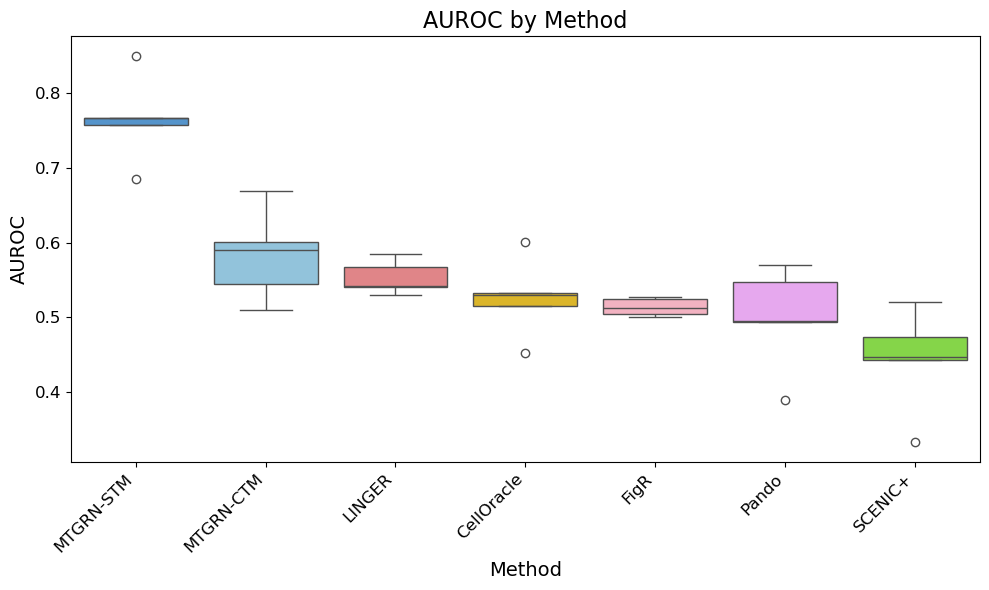

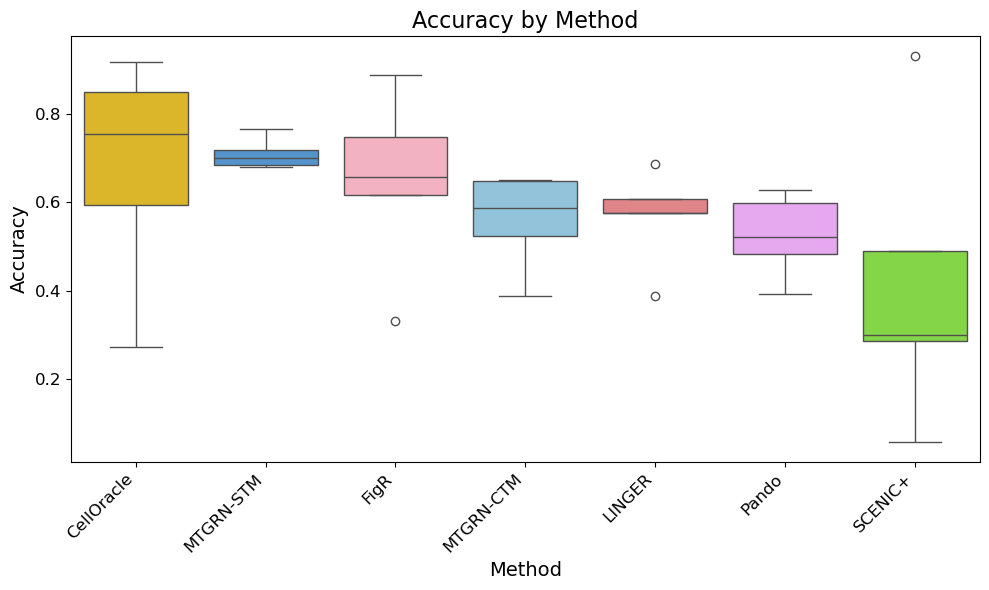

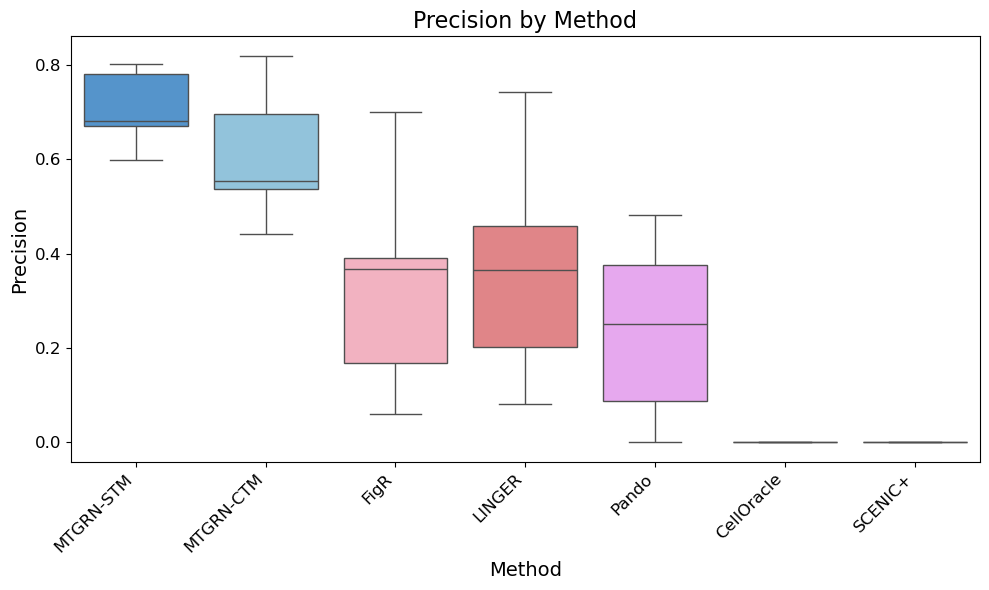

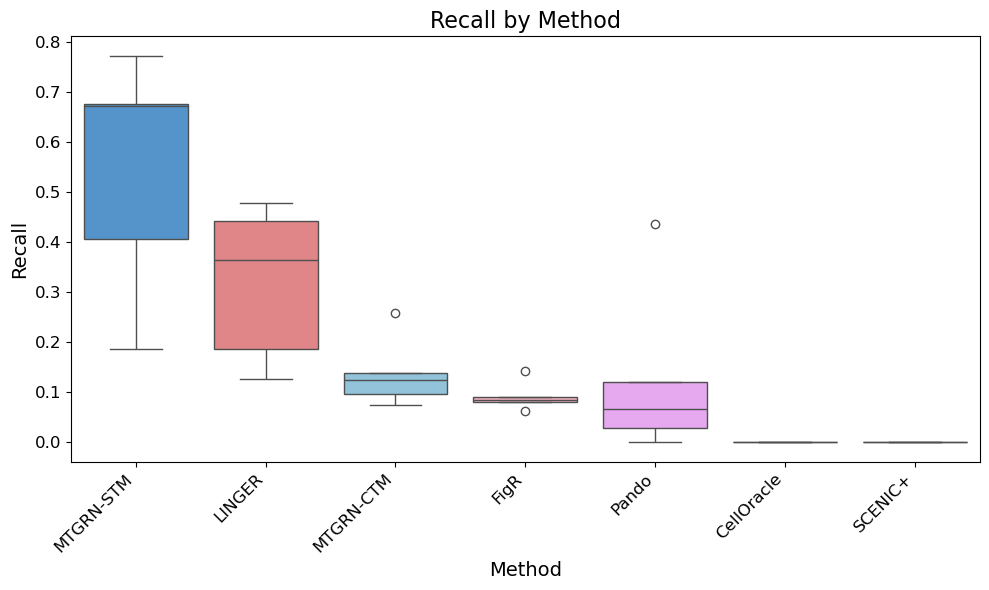

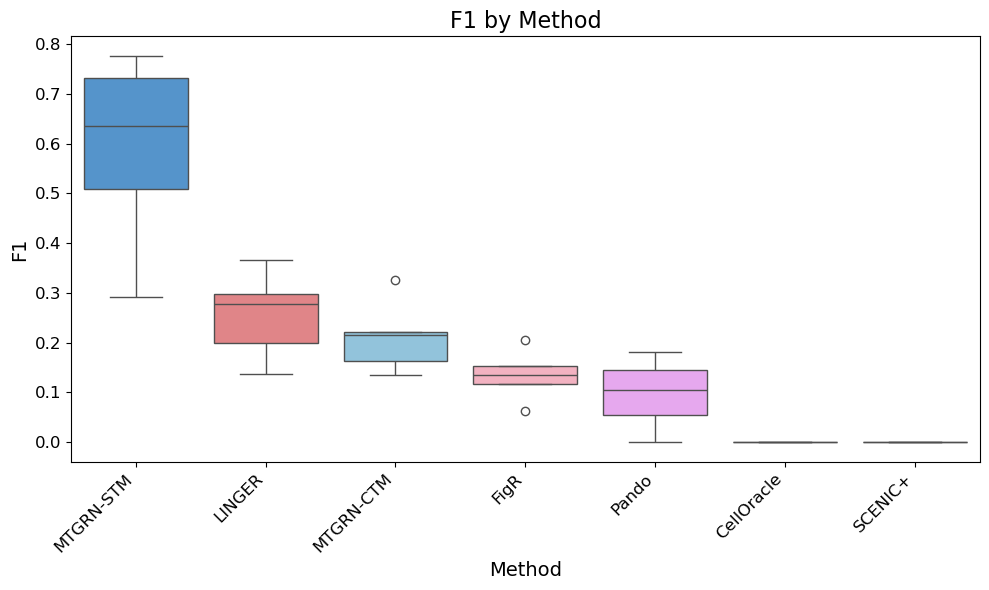

In [85]:
method_color_dict = {
  "MTGRN-STM": "#4195df",
  "MTGRN-CTM": "#86C7E7",
  "LINGER": "#EF767A",
  "CellOracle": "#F9C60D",
  "Pando": "#EF9CFA",
  "SCENIC+": "#82EC32",
  "FigR": "#FDA7BB",
  "GRaNIE": "#F98637"
}

# Selected columns by method box and whisker plot
methods = ["auroc", "accuracy", "precision", "recall", "f1"]

for selected_column in methods:
    metric_ordered_by_auroc = (
        full_metric_df
        .groupby("method_name")[selected_column]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    sanitized_name = selected_column.replace(" ", "_").lower()
    if sanitized_name in ["auroc", "auprc"]:
        sanitized_name = sanitized_name.upper()
    else:
        sanitized_name = sanitized_name.capitalize()

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=full_metric_df, x="method_name", y=selected_column, hue = "method_name", order=metric_ordered_by_auroc, palette=method_color_dict)
    plt.title(f"{sanitized_name} by Method", fontsize=16)
    plt.xlabel("Method", fontsize=14)
    plt.ylabel(sanitized_name, fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    
    plt.savefig(eval_metric_result_dir / f"{sanitized_name.lower()}_by_method_boxplot.png", dpi=300, bbox_inches="tight")
    
    plt.show()

### Plot ROC curves

In [21]:
full_metric_df

,method_name,sample_name,auroc,early_precision,accuracy,precision,recall,f1,n_edges,n_pos,n_neg,score_threshold
0,SCENIC+,hepatocytes_1,0.241636,0.0269,0.021818,0.000000,0.000000,0.000000,275,269,6,0.5
1,LINGER,hepatocytes_1,0.684120,0.0154,0.618590,0.666667,0.454545,0.540541,312,154,158,0.5
2,CellOracle,hepatocytes_1,0.591654,0.1309,0.576238,0.000000,0.000000,0.000000,3089,1309,1780,0.5
3,Pando,hepatocytes_1,NaN,0.0000,NaN,0.000000,0.000000,0.000000,0,0,0,0.5
4,FigR,hepatocytes_1,0.467666,0.1305,0.552473,0.333333,0.026054,0.048330,2992,1305,1687,0.5
5,MTGRN-STM,hepatocytes_1,0.835136,0.4895,0.755330,0.718236,0.689285,0.703463,11726,4937,6789,0.5
6,SCENIC+,hepatocytes_3,0.383308,0.0219,0.075949,0.000000,0.000000,0.000000,237,219,18,0.5
7,LINGER,hepatocytes_3,0.663281,0.0151,0.581940,0.654762,0.364238,0.468085,299,151,148,0.5
8,CellOracle,hepatocytes_3,0.568013,0.1273,0.569059,0.000000,0.000000,0.000000,2954,1273,1681,0.5
9,Pando,hepatocytes_3,0.431818,0.0011,0.421053,0.000000,0.000000,0.000000,19,11,8,0.5


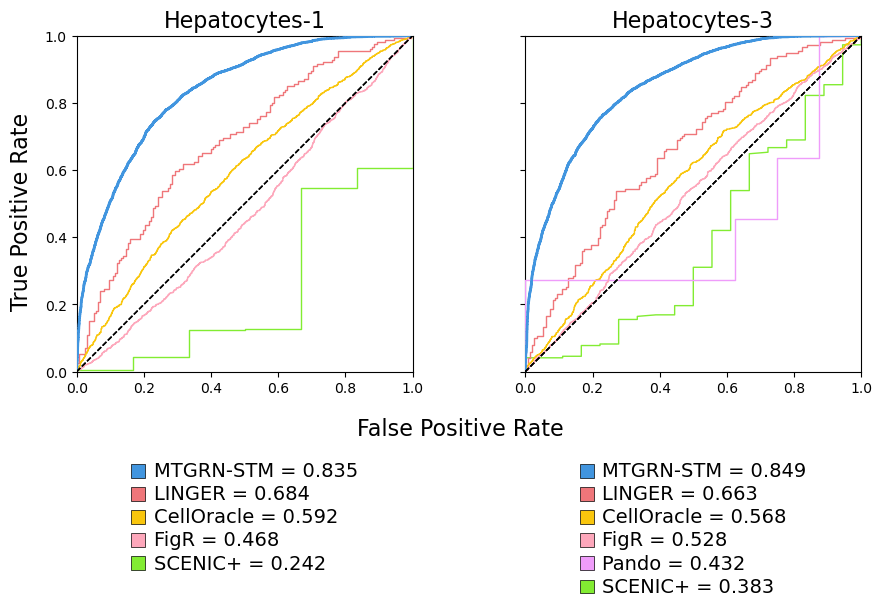

In [31]:
sample_to_title_map = {
    # "E7.5_rep1": "mESC",
    # "buffer_1": "Macr-1",
    # "buffer_2": "Macr-2",
    # "buffer_3": "Macr-3",
    # "WT_D13_rep1": "iPSC",
    # "sample_1": "K562",
    "hepatocytes_1": "Hepatocytes-1",
    "hepatocytes_3": "Hepatocytes-3",
}

method_color_dict = {
  "MTGRN-STM": "#4195df",
  "MTGRN-CTM": "#86C7E7",
  "LINGER": "#EF767A",
  "CellOracle": "#F9C60D",
  "Pando": "#EF9CFA",
  "SCENIC+": "#82EC32",
  "FigR": "#FDA7BB",
  "GRaNIE": "#F98637"
}

combined_fig, combined_axes = plt.subplots(
    nrows=1,
    ncols=len(sample_to_title_map),
    figsize=(9, 8),
    sharex=True,
    sharey=True,
    squeeze=False,
)
combined_axes = np.array(combined_axes, ndmin=1).ravel()

cell_type_method_auroc = {}
for i, sample_name in enumerate(sample_to_title_map.keys()):
    
    ax = combined_axes[i]
    
    ax.set_box_aspect(1)
    
    auroc_text_lines = []
    cell_type_method_auroc[sample_name] = {}
    
    for method in label_by_method_dict[sample_name].keys():
        labels = label_by_method_dict[sample_name][method]
        scores = score_by_method_dict[sample_name][method]

        labels = np.asarray(labels).astype(int).ravel()
        scores = np.asarray(scores).astype(float).ravel()
        
        if len(np.unique(labels)) < 2:
            continue

        fpr, tpr, _ = roc_curve(labels, scores)
        auroc = roc_auc_score(labels, scores)
        cell_type_method_auroc[sample_name][method] = auroc

        rand_scores = plotting_utils._create_random_distribution(scores)
        rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)
        rand_auroc = roc_auc_score(labels, rand_scores)
        
        method_color = method_color_dict.get(method, "#747474")
        auroc_text_lines.append((method, auroc, method_color))

        if method in ["MTGRN-STM", "MTGRN-CTM"]:
            line_weight = 2
            
        else:
            line_weight = 1
            
        roc_line_color = method_color_dict.get(method, "#747474")

        ax.plot(
            fpr,
            tpr,
            lw=line_weight,
            color=roc_line_color,
            label=f"{method} = {auroc:.3f}",
            zorder=3,
        )
        
        ax.plot(
            [0, 1],
            [0, 1],
            color="black",
            linestyle="--",
            lw=1,
            alpha=0.6,
            zorder=4,
        )
        
        # ax.set_xticklabels([])
        # ax.set_yticklabels([])
        
        # ax.set_xticks([])
        # ax.set_yticks([])

    auroc_text_lines_sorted = sorted(
        auroc_text_lines,
        key=lambda x: x[1],
        reverse=True,
    )

    ax.set_title(sample_to_title_map.get(sample_name, sample_name), fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    legend_rows = []

    for method, auroc, method_color in auroc_text_lines_sorted:
        # Small colored square
        color_box = DrawingArea(12, 12, 0, 0)
        color_box.add_artist(
            Rectangle(
                (0, 1), 10, 10,
                facecolor=method_color,
                edgecolor="black",
                linewidth=0.5,
            )
        )

        # Black text
        label_text = TextArea(
            f"{method} = {auroc:.3f}",
            textprops=dict(
                color="black",
                fontsize=14,
            ),
        )

        # Put square and text side-by-side
        row = HPacker(
            children=[color_box, label_text],
            align="center",
            pad=0,
            sep=4,
        )

        legend_rows.append(row)

    packed_legend = VPacker(
        children=legend_rows,
        align="left",
        pad=0,
        sep=3,
    )

    anchored_text = AnchoredOffsetbox(
        loc="upper center",
        child=packed_legend,
        pad=0.0,
        frameon=False,
        bbox_to_anchor=(0.5, -0.25),
        bbox_transform=ax.transAxes,
        borderpad=0.4,
    )

    ax.add_artist(anchored_text)

combined_fig.text(
    0.5,
    0.32,
    "False Positive Rate",
    ha="center",
    fontsize=16,
)

combined_fig.text(
    0.00,
    0.60,
    "True Positive Rate",
    va="center",
    rotation="vertical",
    fontsize=16,
)

combined_fig.subplots_adjust(
    left=0.03,
    right=0.99,
    bottom=0.40,
    top=0.82,
    wspace=0.08,
)

plt.show()

combined_fig.savefig(all_evaluation_plot_dir / f"models_vs_own_test_set_roc.png", dpi=300, bbox_inches="tight")

/tmp/ipykernel_2810044/1983160157.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right")


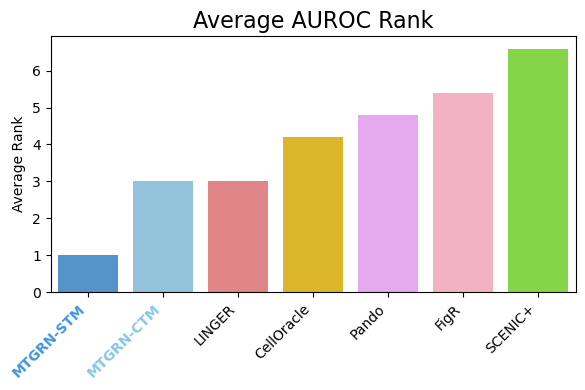

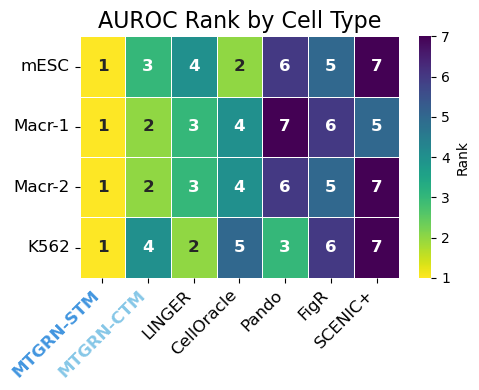

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def auroc_dict_to_long_df(cell_type_method_auroc):
    """
    Converts:
        {
            sample: {
                method: auroc,
                ...
            },
            ...
        }

    into a long dataframe with columns:
        experiment, method, auroc
    """
    rows = []

    for experiment, method_scores in cell_type_method_auroc.items():
        for method, auroc in method_scores.items():
            rows.append({
                "experiment": experiment,
                "method": method,
                "auroc": auroc,
            })

    return pd.DataFrame(rows)


def rank_methods_by_experiment(df):
    """
    Calculates method rank within each experiment/cell type.
    Higher AUROC = better rank.
    """
    all_ranks_df = df.copy()

    all_ranks_df["rank"] = (
        all_ranks_df
        .groupby("experiment")["auroc"]
        .rank(method="min", ascending=False)
        .astype(int)
    )

    return all_ranks_df.sort_values(["experiment", "rank"])


def avg_rank_by_method(all_ranks_df):
    """
    Calculates average rank for each method across experiments.
    Lower average rank = better.
    """
    rank_df = (
        all_ranks_df
        .groupby("method", as_index=False)
        .agg(avg_rank=("rank", "mean"))
        .sort_values("avg_rank", ascending=True)
        .reset_index(drop=True)
    )

    return rank_df


def avg_rank_by_method_plot(avg_rank_df, method_color_dict, title, rename_map=None):
    fig = plt.figure(figsize=(6, 4))

    if rename_map is None:
        rename_map = {}

    order = avg_rank_df["method"].tolist()

    sns.barplot(
        data=avg_rank_df,
        x="method",
        y="avg_rank",
        order=order,
        hue="method",
        palette=method_color_dict,
        dodge=False,
        legend=False,
    )

    ax = plt.gca()

    new_labels = []
    for tick in ax.get_xticklabels():
        original = tick.get_text()
        new = rename_map.get(original, original)
        new_labels.append(new)

        if new in {"MTGRN", "MTGRN-STM", "MTGRN-CTM"}:
            tick.set_color(method_color_dict.get(original, "black"))
            tick.set_fontweight("bold")
        else:
            tick.set_color("black")
            tick.set_fontweight("normal")

    ax.set_xticklabels(new_labels, rotation=45, ha="right")

    ax.set_ylabel("Average Rank")
    ax.set_xlabel("")
    ax.set_title(title, fontsize=16)

    plt.tight_layout()
    return fig


def experiment_by_method_rank_heatmap(
    all_ranks_df,
    rank_df,
    method_color_dict,
    title=None,
    experiment_order=None,
    rename_map=None,
):
    if rename_map is None:
        rename_map = {}

    rank_heatmap_df = all_ranks_df.pivot(
        index="experiment",
        columns="method",
        values="rank",
    )

    method_order = rank_df["method"].tolist()

    if experiment_order is None:
        experiment_order = rank_heatmap_df.index.tolist()

    rank_heatmap_df = rank_heatmap_df.reindex(
        index=experiment_order,
        columns=method_order,
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    sns.heatmap(
        rank_heatmap_df,
        annot=True,
        fmt=".0f",
        cmap="viridis_r",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Rank"},
        annot_kws={"size": 12, "fontweight": "bold"},
        ax=ax,
    )

    new_labels = []
    for tick in ax.get_xticklabels():
        original = tick.get_text()
        new = rename_map.get(original, original)
        new_labels.append(new)

        if new in {"MTGRN", "MTGRN-STM", "MTGRN-CTM"}:
            tick.set_color(method_color_dict.get(original, "black"))
            tick.set_fontweight("bold")
        else:
            tick.set_color("black")
            tick.set_fontweight("normal")
            
    # Rename y-axis experiment/sample labels
    new_y_labels = []
    for tick in ax.get_yticklabels():
        original = tick.get_text()
        new = rename_map.get(original, original)
        new_y_labels.append(new)

    ax.set_yticklabels(new_y_labels, rotation=0, fontsize=12)
    ax.set_xticklabels(new_labels, rotation=45, ha="right", fontsize=12)

    if title is None:
        ax.set_title("Method AUPRC Rank by Cell Type", fontsize=16)
    else:
        ax.set_title(title, fontsize=16)    
    
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout()
    return fig

method_color_dict = {
    "MTGRN-STM": "#4195df",
    "MTGRN-CTM": "#86C7E7",
    "LINGER": "#EF767A",
    "CellOracle": "#F9C60D",
    "Pando": "#EF9CFA",
    "SCENIC+": "#82EC32",
    "FigR": "#FDA7BB",
}

experiment_order = [
    "E7.5_rep1",
    "buffer_1",
    "buffer_2",
    "sample_1",
]

rename_map = {
    "E7.5_rep1": "mESC",
    "buffer_1": "Macr-1",
    "buffer_2": "Macr-2",
    "sample_1": "K562",
}

auroc_df = auroc_dict_to_long_df(cell_type_method_auroc)

all_ranks_df = rank_methods_by_experiment(auroc_df)
rank_df = avg_rank_by_method(all_ranks_df)

avg_auroc_rank_fig = avg_rank_by_method_plot(
    rank_df,
    method_color_dict=method_color_dict,
    title="Average AUROC Rank",
)

auroc_heatmap_fig = experiment_by_method_rank_heatmap(
    all_ranks_df,
    rank_df,
    method_color_dict=method_color_dict,
    experiment_order=experiment_order,
    rename_map=rename_map,
    title="AUROC Rank by Cell Type",
)

avg_auroc_rank_fig.savefig(
    all_evaluation_plot_dir / "average_auroc_rank.png",
    dpi=300,
    bbox_inches="tight",
)

auroc_heatmap_fig.savefig(
    all_evaluation_plot_dir / "auroc_rank_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)


### Plot PR Curves

In [19]:
def normalize_gene_names(x):
    return pd.Series(list(x)).astype(str).str.strip().str.capitalize()


def make_gt_lookup(gt_tfs, gt_targets, gt_pairs):
    gt_tfs_norm = set(normalize_gene_names(gt_tfs))
    gt_targets_norm = set(normalize_gene_names(gt_targets))

    gt_pairs_norm = set()
    for pair in gt_pairs:
        src, tgt = str(pair).split("\t")
        src = str(src).strip().capitalize()
        tgt = str(tgt).strip().capitalize()
        gt_pairs_norm.add(f"{src}\t{tgt}")

    return gt_tfs_norm, gt_targets_norm, gt_pairs_norm


def make_full_universe(gt_tfs, gt_targets, gt_pairs):
    gt_tfs_norm, gt_targets_norm, gt_pairs_norm = make_gt_lookup(
        gt_tfs,
        gt_targets,
        gt_pairs,
    )

    full_universe = (
        pd.MultiIndex
        .from_product(
            [sorted(gt_tfs_norm), sorted(gt_targets_norm)],
            names=["Source", "Target"],
        )
        .to_frame(index=False)
    )

    full_universe["_edge_key"] = (
        full_universe["Source"].astype(str)
        + "\t"
        + full_universe["Target"].astype(str)
    )

    full_universe["_in_gt"] = (
        full_universe["_edge_key"]
        .isin(gt_pairs_norm)
        .astype("int8")
    )

    return full_universe, (gt_tfs_norm, gt_targets_norm, gt_pairs_norm)


def create_ground_truth_comparison_df(score_df, ground_truth_lookup, ground_truth_name):
    gt_tfs, gt_tgs, gt_pairs_set = ground_truth_lookup

    df = score_df.copy()

    df["Source"] = df["Source"].astype(str).str.strip().str.capitalize()
    df["Target"] = df["Target"].astype(str).str.strip().str.capitalize()

    mask = df["Source"].isin(gt_tfs) & df["Target"].isin(gt_tgs)
    df = df.loc[mask].copy()

    df["_edge_key"] = df["Source"] + "\t" + df["Target"]
    df["_in_gt"] = df["_edge_key"].isin(gt_pairs_set).astype("int8")
    df["ground_truth_name"] = ground_truth_name

    return df


def sample_auprc_10x_negatives(full_universe, random_state=42, neg_pos_ratio=10):
    positives = full_universe.loc[full_universe["_in_gt"] == 1].copy()
    negatives = full_universe.loc[full_universe["_in_gt"] == 0].copy()

    n_pos = len(positives)
    n_neg_sample = min(n_pos * neg_pos_ratio, len(negatives))

    if n_pos == 0 or n_neg_sample == 0:
        return full_universe.iloc[0:0].copy()

    neg_sampled = negatives.sample(
        n=n_neg_sample,
        replace=False,
        random_state=random_state,
    )

    auprc_df = pd.concat([positives, neg_sampled], axis=0)

    auprc_df = (
        auprc_df
        .sample(frac=1.0, random_state=random_state)
        .reset_index(drop=True)
    )

    return auprc_df


Sample: hepatocytes_1
TFs: 13
TGs: 902
Edges: 4937


NameError: name 'make_full_universe' is not defined

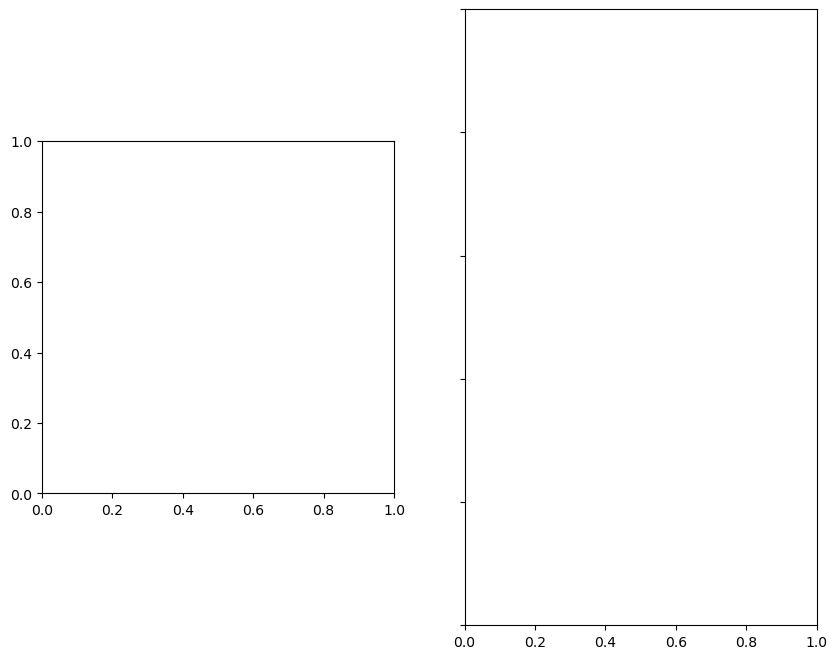

In [18]:
combined_fig, combined_axes = plt.subplots(
    nrows=1,
    ncols=len(sample_to_title_map),
    figsize=(5 * len(sample_to_title_map), 8),
    sharex=True,
    sharey=True,
    squeeze=False,
)

combined_axes = np.array(combined_axes, ndmin=1).ravel()

for i, sample_name in enumerate(sample_to_title_map.keys()):

    ax = combined_axes[i]
    
    ax.set_box_aspect(1)
    
    auprc_text_lines = []

    # Use sample-specific GT
    gt_pairs_sample, gt_tfs_sample, gt_targets_sample = gt_by_sample_dict[sample_name]
    
    print(f"\nSample: {sample_name}")
    print(f"TFs: {len(gt_tfs_sample)}")
    print(f"TGs: {len(gt_targets_sample)}")
    print(f"Edges: {len(gt_pairs_sample)}")

    full_universe, gt_lookup = make_full_universe(
        gt_tfs=gt_tfs_sample,
        gt_targets=gt_targets_sample,
        gt_pairs=gt_pairs_sample,
    )

    full_universe_10x_negatives = sample_auprc_10x_negatives(
        full_universe,
        random_state=42,
        neg_pos_ratio=10,
    )

    eval_df = full_universe_10x_negatives[
        ["Source", "Target", "_in_gt"]
    ].copy()

    print(
        sample_name,
        "positives:",
        int(eval_df["_in_gt"].sum()),
        "negatives:",
        int((eval_df["_in_gt"] == 0).sum()),
        "baseline:",
        eval_df["_in_gt"].mean(),
    )

    for method in label_by_method_dict[sample_name].keys():

        # Use sample-specific method scores
        df_std = standardized_method_dfs[sample_name][method].copy()

        method_labeled_df = create_ground_truth_comparison_df(
            score_df=df_std,
            ground_truth_lookup=gt_lookup,
            ground_truth_name="test_chrom_gt",
        )

        method_scores = (
            method_labeled_df
            .groupby(["Source", "Target"], as_index=False)["Score"]
            .median()
        )

        auprc_df = eval_df.merge(
            method_scores,
            on=["Source", "Target"],
            how="left",
        )

        auprc_df["Score"] = auprc_df["Score"].fillna(0)

        y_auprc = auprc_df["_in_gt"].astype(int).to_numpy()
        s_auprc = auprc_df["Score"].astype(float).to_numpy()

        auprc = average_precision_score(y_auprc, s_auprc)
        prec, rec, _ = precision_recall_curve(y_auprc, s_auprc)

        rand_scores = plotting_utils._create_random_distribution(s_auprc)
        rand_prec, rand_rec, _ = precision_recall_curve(y_auprc, rand_scores)

        method_color = method_color_dict.get(method, "#747474")
        auprc_text_lines.append((method, auprc, method_color))

        line_weight = 2 if method in ["MTGRN-STM", "MTGRN-CTM"] else 1

        ax.step(
            rec,
            prec,
            where="post",
            lw=line_weight,
            color=method_color,
            label="",
            zorder=3,
        )

        ax.step(
            rand_rec,
            rand_prec,
            where="post",
            lw=1,
            linestyle="--",
            color=method_color,
            label="",
            zorder=2,
            alpha=0.75,
        )

    auprc_text_lines_sorted = sorted(
        auprc_text_lines,
        key=lambda x: x[1],
        reverse=True,
    )

    ax.set_title(sample_to_title_map.get(sample_name, sample_name), fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    legend_rows = []

    for method, auprc, method_color in auprc_text_lines_sorted:
        color_box = DrawingArea(12, 12, 0, 0)
        color_box.add_artist(
            Rectangle(
                (0, 1),
                10,
                10,
                facecolor=method_color,
                edgecolor="black",
                linewidth=0.5,
            )
        )

        label_text = TextArea(
            f"{method} = {auprc:.3f}",
            textprops=dict(
                color="black",
                fontsize=14,
            ),
        )

        row = HPacker(
            children=[color_box, label_text],
            align="center",
            pad=0,
            sep=4,
        )

        legend_rows.append(row)

    packed_legend = VPacker(
        children=legend_rows,
        align="left",
        pad=0,
        sep=3,
    )

    anchored_text = AnchoredOffsetbox(
        loc="upper center",
        child=packed_legend,
        pad=0.0,
        frameon=False,
        bbox_to_anchor=(0.5, -0.45),
        bbox_transform=ax.transAxes,
        borderpad=0.4,
    )

    ax.add_artist(anchored_text)

    # ax.tick_params(bottom=False, left=False)
    # ax.set_xticklabels([])
    # ax.set_yticklabels([])

combined_fig.text(
    0.5,
    0.32,
    "Recall",
    ha="center",
    fontsize=16,
)

combined_fig.text(
    -0.01,
    0.65,
    "Precision",
    va="center",
    rotation="vertical",
    fontsize=16,
)

combined_fig.subplots_adjust(
    left=0.04,
    right=0.99,
    bottom=0.45,
    top=0.82,
    wspace=0.08,
)

# plt.xlim([0, 0.02])

plt.show()

combined_fig.savefig(
    all_evaluation_plot_dir / "models_vs_own_test_set_prc.png",
    dpi=300,
    bbox_inches="tight",
)

### Karamveer's method for creating a ground truth evaluation

In [ ]:
def create_ground_truth_comparison_df(score_df, ground_truth_lookup, ground_truth_name):
    # Normalize once
    gt_tfs, gt_tgs, gt_pairs_set = ground_truth_lookup

    src = score_df["Source"]
    tgt = score_df["Target"]

    mask = src.isin(gt_tfs) & tgt.isin(gt_tgs)

    df = score_df.loc[mask].copy()
    # re-use normalized versions so we don't upper twice
    df["Source"] = src.loc[mask].values
    df["Target"] = tgt.loc[mask].values

    key = df["Source"] + "\t" + df["Target"]
    df["_in_gt"] = key.isin(gt_pairs_set).astype("int8")
    df["ground_truth_name"] = ground_truth_name

    return df

import scripts.build_tf_to_tg_train_data as tf_tg_data_builder
model_cell_type = "mESC"
sample_name = "E7.5_rep1"

# Load the full ground truth
cell_type_cache_dir = DATA_DIR / f"{model_cell_type}_cache"
merged_ground_truth_df = pd.read_parquet(cell_type_cache_dir / "merged_ground_truth.parquet")

project_data_dir = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data")
gene_reference_file = gene_ref_file = project_data_dir / "genome_data" / "genome_annotation" / "mm10" / "Mus_musculus.GRCm39.115.gtf.gz"

train_chroms = [str(i) for i in range(1, 16)]
val_chroms = [ str(i) for i in range(16, 18)]
test_chroms = [str(i) for i in range(18, 20)]

# Split genes into train/val/test based on chromosome
train_genes, val_genes, test_genes = tf_tg_data_builder.split_genes_by_chromosome(
    gene_ref_file,
    train_chroms=train_chroms,
    val_chroms=val_chroms,
    test_chroms=test_chroms
    )

gt_train_df, gt_val_df, gt_test_df = tf_tg_data_builder.create_train_val_test_splits(
    merged_ground_truth_df, train_genes, val_genes, test_genes
)

gt_test_df["Source"] = gt_test_df["Source"].astype(str).str.upper()
gt_test_df["Target"] = gt_test_df["Target"].astype(str).str.upper()

# Build TF, TG, and edge sets for quick lookup later
gt = gt_test_df[["Source", "Target"]].dropna()

gt_tfs = set(gt["Source"].unique())
gt_tgs = set(gt["Target"].unique())

gt_pairs = (gt["Source"] + "\t" + gt["Target"]).drop_duplicates()

gt_lookup = (gt_tfs, gt_tgs, set(gt_pairs))

INFO - Splitting genes into train/val/test based on chromosome:
INFO - Extracted GTF attributes: ['gene_id', 'gene_version', 'gene_name', 'gene_source', 'gene_biotype', 'transcript_id', 'transcript_version', 'transcript_name', 'transcript_source', 'transcript_biotype', 'tag', 'transcript_support_level', 'exon_number', 'exon_id', 'exon_version', 'protein_id', 'protein_version', 'ccds_id']
INFO -   - Train set: 62,426 genes (chroms 1-9)
INFO -   - Validation set: 5,700 genes (chroms 16-17)
INFO -   - Test set: 4,099 genes (chroms 18-19)
INFO - Train interactions: 6590425
INFO - Validation interactions: 580265
INFO - Test interactions: 480491


Test gt df shape: (480491, 2)


---

## Predictions per epoch

In [ ]:
model_cell_type = "Macrophage"
model_training_sample = "buffer_3"

chkpt_dir = utils.find_latest_checkpoint(model_cell_type, model_training_sample).parent
print(f"Using checkpoint directory: {chkpt_dir.name}")

chkpt_files = list(chkpt_dir.glob("epoch=*-val_auroc=*-val_loss=*.ckpt"))
if not chkpt_files:
    logging.warning(f"No checkpoint files found for {model_training_sample} in {chkpt_dir.name}")

chkpt_files.sort(key=lambda f: int(f.stem.split("-")[0].split("=")[1]), reverse=False)
chkpt_nums = [int(f.stem.split("-")[0].split("=")[1]) for f in chkpt_files]

# only plot every 10 epochs
chkpt_files = [f for f in chkpt_files if int(f.stem.split("-")[0].split("=")[1]) % 10 == 0]
print(f"Found {len(chkpt_files)} checkpoint files with epochs: {chkpt_nums[:2]} ... {chkpt_nums[-2:]}")

per_epoch_plot_data = {}
all_comparison_df_list = []
subset_size = 3000
for chkpt_file in tqdm(chkpt_files, desc="Evaluating Checkpoints", ncols=100):
    dataset_split_type = "val"
    
    epoch_num = int(chkpt_file.stem.split("-")[0].split("=")[1])
    
    tf_tg_model_checkpoints[model_cell_type][model_training_sample] = chkpt_file
    
    comparison_result = run_prediction_vs_test_set(
        tf_tg_model_checkpoints=tf_tg_model_checkpoints,
        model_cell_type=model_cell_type,
        model_training_sample=model_training_sample,
        test_set_cell_type=model_cell_type,
        evaluation_sample=model_training_sample,
        dataset_split_type=dataset_split_type,
        subset_size=subset_size,
        show_progress_bar=False,
    )
        
    metric_df = comparison_result["metric_df"]
    metric_df["epoch"] = epoch_num
    
    plot_data = comparison_result["plot_data"]
    
    all_labels_flat = plot_data[0]
    all_scores_flat = plot_data[1]
    
    title = f"{model_cell_type} {model_training_sample}\nEpoch {epoch_num}"
    
    per_epoch_plot_data[title] = (all_labels_flat, all_scores_flat)
    
    all_comparison_df_list.append(metric_df)
    
all_epoch_df = pd.concat(all_comparison_df_list, ignore_index=True)

            

INFO - Latest checkpoint for Macrophage buffer_3: Job 3696133 Epoch 126


Using checkpoint directory: tf_tg_train_buffer_3_3696133
Found 13 checkpoint files with epochs: [0, 1] ... [125, 126]


Plotting Histograms: 100%|██████████████████████████████████████████| 13/13 [00:02<00:00,  4.90it/s]


In [187]:

plot_dir = PROJECT_DIR / "plots" / "histogram_per_epoch" / f"{model_cell_type}_{model_training_sample}"
plot_dir.mkdir(parents=True, exist_ok=True)
(plot_dir / "epoch_figs").mkdir(parents=True, exist_ok=True)

for title in tqdm(per_epoch_plot_data.keys(), desc="Plotting Histograms", ncols=100):        
    labels = per_epoch_plot_data[title][0]
    scores = per_epoch_plot_data[title][1]
    
    epoch = int(title.split("\nEpoch ")[1])

    histogram_fig = plotting_utils.plot_score_histograms(
        labels=labels,
        scores=scores,
        n_bins=50,
        y_log=False,
        panel_kind="hist",
        density=False,
        title = title,
        y_lim=(0, 100),
        x_lim=(0, 1)
    )

    histogram_fig.savefig(plot_dir / "epoch_figs" / f"epoch_{epoch}.png")
    plt.close(histogram_fig)
    
# Combine all histogram plots into a GIF in epoch order
import imageio.v3 as iio
gif_path = plot_dir / f"{model_cell_type}_{model_training_sample}_histograms.gif"

filenames = sorted(plot_dir.glob("epoch_figs/epoch_*.png"), key=lambda f: int(f.stem.split("_")[1]))
images = [iio.imread(str(f)) for f in filenames]

default_duration = 200
# The lagging
lag = 2000
# Pause the GIF by extending the duration of the last frame
duration = [default_duration] * (len(images)-1) + [lag]
iio.imwrite(gif_path, images, duration=duration, loop=0)

Plotting Histograms: 100%|██████████████████████████████████████████| 13/13 [00:02<00:00,  6.49it/s]
